# 🍷 Wine Quality Prediction — From Raw Chemistry to a Digital Sommelier

**Dataset:** UCI Wine Quality (Vinho Verde, Portugal) — `winequality-red.csv` + `winequality-white.csv`
**Author:** ericmaniraguha@gmail.com
**Goal:** predict the sensory quality score of a wine from its physicochemical lab measurements, then
package the result as an interactive *Digital Sommelier* web app.

---

### How to read this notebook

Every numbered section opens with a **🔎 Highlights** box that states, in three lines:
*what we do*, *why it matters*, and *what to look for in the output*. Read the box, run the cells,
then compare what you see against the "look for" line.

| # | Section | # | Section |
|---|---------|---|---------|
| 01 | Project Overview & Problem Framing | 11 | Supervised Learning |
| 02 | Import Libraries | 12 | Hyperparameter Tuning |
| 03 | Load the Dataset | 13 | Model Evaluation & Comparison |
| 04 | Understand the Data Structure | 14 | Model Interpretation (importance + SHAP) |
| 05 | Data Quality Assessment | 15 | Business / Winery Insights |
| 06 | Exploratory Data Analysis | 16 | Final Model |
| 07 | Feature Engineering & Target | 17 | Save Model |
| 08 | Train/Test Split | 18 | Streamlit Digital Sommelier |
| 09 | Feature Scaling | 19 | Conclusion & Limitations |
| 10 | Unsupervised Learning | | |

## 00. Environment setup (run once)

> **🔎 Highlights**
> - **What:** install the Python libraries this notebook needs.
> - **Why:** the notebook fails at section 02 if `pandas` / `scikit-learn` are missing.
> - **Look for:** no red tracebacks; then **restart the kernel** before continuing.

Uncomment the line below the first time you open this notebook. `xgboost` and `shap` are *optional* —
every section degrades gracefully if they are unavailable for your Python version.

In [1]:
# %pip install -r requirements.txt

# Optional extras (skip without breaking anything):
# %pip install xgboost shap

---
## 01. Project Overview & Problem Framing

> **🔎 Highlights**
> - **What:** turn a vague wish ("make better wine") into a measurable ML problem with a defined target, metric and success bar.
> - **Why:** the framing decides everything downstream — regression vs classification, which metric you optimise, and what "good enough" means.
> - **Look for:** nothing runs here. This is the contract the rest of the notebook is judged against.

### The business situation
A winery runs physicochemical lab tests on every batch (acidity, sugar, sulphur dioxide, alcohol, …).
Sensory quality, however, is scored by a **panel of human tasters** — slow, expensive, and
unavailable *before* bottling. If chemistry alone can predict the panel's score, the winery gets an
instant quality estimate at any point in production.

### Problem statement
> Given 11 physicochemical measurements of a wine, predict the median sensory quality score (0–10)
> that a panel of three certified tasters would award.

### Framing decisions

| Decision | Choice | Rationale |
|---|---|---|
| Task type | **Regression** (primary) | `quality` is ordinal 3–9; the distance between 5 and 8 is meaningful, so squared error is informative. |
| Secondary view | Binary "premium" flag (`quality >= 7`) | What the sommelier app actually badges; reported alongside regression. |
| Primary metric | **RMSE** | Same unit as the score; punishes the badly-missed bottles that would embarrass a sommelier. |
| Support metrics | MAE, R², ±0.5-point hit-rate | MAE = typical miss; R² = variance explained; hit-rate = "would a taster agree?" |
| Success bar | Beat the mean-predictor baseline by **≥ 20 % RMSE** | A model must cut typical error by at least a fifth before it is worth routing production decisions through it. Published work on this dataset lands around RMSE 0.6–0.7, so this is ambitious but attainable. |
| Constraint | Red and white modelled **together**, with wine type as a feature | One deployable model; lets us test whether type matters after chemistry is accounted for. |

### Known limitations up front
- `quality` is a **subjective human median**, not a physical constant — there is an irreducible noise floor.
- The data is one region (Vinho Verde) and one era; it will not transfer to Bordeaux or Napa unchanged.
- Observational data ⇒ every relationship found is **correlational**, not causal. See section 15.

---
## 02. Import Libraries

> **🔎 Highlights**
> - **What:** import every library once, pin the random seed, and set a consistent plot style.
> - **Why:** one seed (`RANDOM_STATE = 42`) makes every split, cluster and forest reproducible run-to-run.
> - **Look for:** the version table printed at the end, and the ✅/⚠️ flags for the optional libraries.

In [2]:
import os
import json
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib

from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RandomizedSearchCV,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# --- reproducibility -------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- plotting defaults -----------------------------------------------------
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

RED = "#8C1C3A"     # house colours used throughout
WHITE = "#D9C16B"

# --- project folders -------------------------------------------------------
PROJECT_DIR = Path.cwd()
FIG_DIR = PROJECT_DIR / "figures"
MODEL_DIR = PROJECT_DIR / "models"
OUT_DIR = PROJECT_DIR / "outputs"
for d in (FIG_DIR, MODEL_DIR, OUT_DIR):
    d.mkdir(exist_ok=True)

# --- optional libraries ----------------------------------------------------
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False


def rmse(y_true, y_pred):
    """Root mean squared error (version-proof across sklearn releases)."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


print(f"python       {sys.version.split()[0]}")
print(f"numpy        {np.__version__}")
print(f"pandas       {pd.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print(f"xgboost      {'✅ available' if HAS_XGB else '⚠️  not installed — that section will be skipped'}")
print(f"shap         {'✅ available' if HAS_SHAP else '⚠️  not installed — fallback importance will be used'}")
print(f"\nworking dir  {PROJECT_DIR}")

python       3.14.7
numpy        2.5.3
pandas       3.0.5
scikit-learn 1.9.1
xgboost      ⚠️  not installed — that section will be skipped
shap         ⚠️  not installed — fallback importance will be used

working dir  C:\Users\eric_admin\Documents\wine-predictions


---
## 03. Load the Wine Quality Dataset

> **🔎 Highlights**
> - **What:** read both CSVs (they are **semicolon-separated**, not comma), tag each row `red`/`white`, and concatenate.
> - **Why:** one combined frame lets a single model serve both product lines and lets us compare the two styles directly.
> - **Look for:** 1,599 red + 4,898 white = **6,497 rows × 13 columns**, and identical column names in both files.

In [3]:
RED_CSV = PROJECT_DIR / "winequality-red.csv"
WHITE_CSV = PROJECT_DIR / "winequality-white.csv"

# NOTE: the UCI files use ';' as the delimiter — read_csv's default ',' would give you one column.
red = pd.read_csv(RED_CSV, sep=";")
white = pd.read_csv(WHITE_CSV, sep=";")

print(f"red   : {red.shape[0]:>5,} rows x {red.shape[1]} cols")
print(f"white : {white.shape[0]:>5,} rows x {white.shape[1]} cols")
assert list(red.columns) == list(white.columns), "column mismatch between the two files"

red["wine_type"] = "red"
white["wine_type"] = "white"

df = pd.concat([red, white], ignore_index=True)

# tidy column names: 'fixed acidity' -> 'fixed_acidity'
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

print(f"\ncombined: {df.shape[0]:,} rows x {df.shape[1]} cols")
df.head()

red   : 1,599 rows x 12 cols
white : 4,898 rows x 12 cols

combined: 6,497 rows x 13 cols


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,wine_type
0,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5,red
1,7.8000,0.8800,0.0000,2.6000,0.0980,25.0000,67.0000,0.9968,3.2000,0.6800,9.8000,5,red
2,7.8000,0.7600,0.0400,2.3000,0.0920,15.0000,54.0000,0.9970,3.2600,0.6500,9.8000,5,red
3,11.2000,0.2800,0.5600,1.9000,0.0750,17.0000,60.0000,0.9980,3.1600,0.5800,9.8000,6,red
4,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5,red


---
## 04. Understand the Data Structure

> **🔎 Highlights**
> - **What:** inspect dtypes, memory, and the five-number summary of every feature; document what each variable *means*.
> - **Why:** you cannot spot an impossible value (negative acidity, pH of 14) until you know the physically plausible range.
> - **Look for:** all 11 features numeric `float64`, `quality` integer, and the huge scale gap — `total_sulfur_dioxide` runs to ~440 while `density` sits near 0.99. That gap is exactly why section 09 exists.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   ph                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 689.4 KB


In [5]:
FEATURE_GLOSSARY = pd.DataFrame(
    [
        ("fixed_acidity",        "g(tartaric acid)/dm³", "Non-volatile acids; the backbone of tartness."),
        ("volatile_acidity",     "g(acetic acid)/dm³",   "Acetic acid. High levels = vinegar fault."),
        ("citric_acid",          "g/dm³",                "Adds freshness; usually small amounts."),
        ("residual_sugar",       "g/dm³",                "Sugar left after fermentation. >45 = sweet wine."),
        ("chlorides",            "g(sodium chloride)/dm³", "Saltiness."),
        ("free_sulfur_dioxide",  "mg/dm³",               "Active SO₂; prevents microbial growth/oxidation."),
        ("total_sulfur_dioxide", "mg/dm³",               "Free + bound SO₂. >50 becomes perceptible."),
        ("density",              "g/cm³",                "Close to water; driven by sugar and alcohol."),
        ("pH",                   "0–14",                 "Acidity scale; most wines sit between 3 and 4."),
        ("sulphates",            "g(potassium sulphate)/dm³", "Additive; contributes to SO₂ levels."),
        ("alcohol",              "% vol",                "Ethanol by volume."),
        ("quality",              "score 0–10",           "TARGET: median of ≥3 blind sensory ratings."),
        ("wine_type",            "red / white",          "Product line (added by us during load)."),
    ],
    columns=["feature", "unit", "meaning"],
)
FEATURE_GLOSSARY

,feature,unit,meaning
0,fixed_acidity,g(tartaric acid)/dm³,Non-volatile acids; the backbone of tartness.
1,volatile_acidity,g(acetic acid)/dm³,Acetic acid. High levels = vinegar fault.
2,citric_acid,g/dm³,Adds freshness; usually small amounts.
3,residual_sugar,g/dm³,Sugar left after fermentation. >45 = sweet wine.
4,chlorides,g(sodium chloride)/dm³,Saltiness.
5,free_sulfur_dioxide,mg/dm³,Active SO₂; prevents microbial growth/oxidation.
6,total_sulfur_dioxide,mg/dm³,Free + bound SO₂. >50 becomes perceptible.
7,density,g/cm³,Close to water; driven by sugar and alcohol.
8,pH,0–14,Acidity scale; most wines sit between 3 and 4.
9,sulphates,g(potassium sulphate)/dm³,Additive; contributes to SO₂ levels.


In [6]:
summary = df.describe().T
summary["range"] = summary["max"] - summary["min"]
summary["cv"] = summary["std"] / summary["mean"]          # coefficient of variation
summary["skew"] = df.select_dtypes("number").skew()
summary[["count", "mean", "std", "min", "50%", "max", "range", "cv", "skew"]]

,count,mean,std,min,50%,max,range,cv,skew
fixed_acidity,"6,497.0000",7.2153,1.2964,3.8000,7.0000,15.9000,12.1000,0.1797,1.7233
volatile_acidity,"6,497.0000",0.3397,0.1646,0.0800,0.2900,1.5800,1.5000,0.4847,1.4951
citric_acid,"6,497.0000",0.3186,0.1453,0.0000,0.3100,1.6600,1.6600,0.4561,0.4717
residual_sugar,"6,497.0000",5.4432,4.7578,0.6000,3.0000,65.8000,65.2000,0.8741,1.4354
chlorides,"6,497.0000",0.0560,0.0350,0.0090,0.0470,0.6110,0.6020,0.6252,5.3998
free_sulfur_dioxide,"6,497.0000",30.5253,17.7494,1.0000,29.0000,289.0000,288.0000,0.5815,1.2201
total_sulfur_dioxide,"6,497.0000",115.7446,56.5219,6.0000,118.0000,440.0000,434.0000,0.4883,-0.0012
density,"6,497.0000",0.9947,0.0030,0.9871,0.9949,1.0390,0.0519,0.0030,0.5036
ph,"6,497.0000",3.2185,0.1608,2.7200,3.2100,4.0100,1.2900,0.0500,0.3868
sulphates,"6,497.0000",0.5313,0.1488,0.2200,0.5100,2.0000,1.7800,0.2801,1.7973


In [7]:
print("Target distribution (quality score):")
q = df["quality"].value_counts().sort_index()
print(pd.DataFrame({"count": q, "pct": (100 * q / len(df)).round(1)}))
print(f"\nDistinct scores present: {sorted(df['quality'].unique())}")
print("→ scores 0,1,2 and 10 never occur; the panel clusters hard on 5–6.")

Target distribution (quality score):
         count     pct
quality               
3           30  0.5000
4          216  3.3000
5         2138 32.9000
6         2836 43.7000
7         1079 16.6000
8          193  3.0000
9            5  0.1000

Distinct scores present: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
→ scores 0,1,2 and 10 never occur; the panel clusters hard on 5–6.


---
## 05. Data Quality Assessment

> **🔎 Highlights**
> - **What:** five checks — missing values, duplicates, physically invalid values, outliers, dtypes — each with an explicit *decision*.
> - **Why:** this is the step that silently decides your score. Duplicates in particular leak between train and test and inflate every metric you report.
> - **Look for:** **0 missing**, but **~1,177 exact duplicate rows**. We drop them, and explain why. Outliers are real wines, so we keep them and let tree models absorb them.

### 05.1 Missing values

In [8]:
missing = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (100 * df.isna().mean()).round(2),
})
print(missing)
print(f"\nTotal missing cells: {int(df.isna().sum().sum())}")
print("DECISION: none missing → no imputation needed. (If there were, we'd use median-by-wine_type.)")

                      n_missing  pct_missing
fixed_acidity                 0       0.0000
volatile_acidity              0       0.0000
citric_acid                   0       0.0000
residual_sugar                0       0.0000
chlorides                     0       0.0000
free_sulfur_dioxide           0       0.0000
total_sulfur_dioxide          0       0.0000
density                       0       0.0000
ph                            0       0.0000
sulphates                     0       0.0000
alcohol                       0       0.0000
quality                       0       0.0000
wine_type                     0       0.0000

Total missing cells: 0
DECISION: none missing → no imputation needed. (If there were, we'd use median-by-wine_type.)


### 05.2 Duplicate rows

Twelve floating-point measurements matching *exactly* across two rows is not a coincidence — these are
repeated lab entries for the same batch. Left in place they land in both train and test, so the model
"predicts" rows it has already memorised and your test RMSE becomes fiction.

In [9]:
dups_total = df.duplicated().sum()
dups_by_type = df.groupby("wine_type").apply(lambda g: g.duplicated().sum())

print(f"Exact duplicate rows: {dups_total:,}  ({100*dups_total/len(df):.1f}% of the data)")
print("\nBy wine type:")
print(dups_by_type)

print("\nExample of a duplicated record:")
dup_mask = df.duplicated(keep=False)
display(df[dup_mask].sort_values(list(df.columns)).head(4))

Exact duplicate rows: 1,177  (18.1% of the data)

By wine type:
wine_type
red      240
white    937
dtype: int64

Example of a duplicated record:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,wine_type
6270,4.9000,0.3350,0.1400,1.3000,0.0360,69.0000,168.0000,0.9921,3.4700,0.4600,10.4667,5,white
6271,4.9000,0.3350,0.1400,1.3000,0.0360,69.0000,168.0000,0.9921,3.4700,0.4600,10.4667,5,white
5540,4.9000,0.3450,0.3400,1.0000,0.0680,32.0000,143.0000,0.9914,3.2400,0.4000,10.1000,5,white
5549,4.9000,0.3450,0.3400,1.0000,0.0680,32.0000,143.0000,0.9914,3.2400,0.4000,10.1000,5,white


In [10]:
before = len(df)
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"DECISION: drop duplicates → {before:,} rows becomes {len(df_clean):,} rows "
      f"(removed {before - len(df_clean):,}).")
print("\nQuality distribution barely shifts, so we have not biased the target:")
print(pd.DataFrame({
    "before_pct": (100 * df["quality"].value_counts(normalize=True)).round(1),
    "after_pct": (100 * df_clean["quality"].value_counts(normalize=True)).round(1),
}).sort_index())

DECISION: drop duplicates → 6,497 rows becomes 5,320 rows (removed 1,177).

Quality distribution barely shifts, so we have not biased the target:
         before_pct  after_pct
quality                       
3            0.5000     0.6000
4            3.3000     3.9000
5           32.9000    32.9000
6           43.7000    43.7000
7           16.6000    16.1000
8            3.0000     2.8000
9            0.1000     0.1000


### 05.3 Physically invalid values

In [11]:
# Every feature here is a concentration or a percentage: negatives are impossible.
numeric_cols = df_clean.select_dtypes("number").columns.tolist()
negatives = (df_clean[numeric_cols] < 0).sum()

checks = {
    "negative values anywhere": int(negatives.sum()),
    "pH outside 2.0-4.5":       int(((df_clean.ph < 2.0) | (df_clean.ph > 4.5)).sum()),
    "alcohol outside 5-20 %":   int(((df_clean.alcohol < 5) | (df_clean.alcohol > 20)).sum()),
    "density outside 0.95-1.05": int(((df_clean.density < 0.95) | (df_clean.density > 1.05)).sum()),
    "free SO2 > total SO2":     int((df_clean.free_sulfur_dioxide > df_clean.total_sulfur_dioxide).sum()),
    "zero quality":             int((df_clean.quality <= 0).sum()),
}
for k, v in checks.items():
    flag = "✅" if v == 0 else "⚠️"
    print(f"{flag} {k:<28} {v}")

print("\nDECISION: no impossible records → nothing to repair.")
print("The 'free <= total SO2' check matters: it is a hard chemical constraint, and it holds.")

✅ negative values anywhere     0
✅ pH outside 2.0-4.5           0
✅ alcohol outside 5-20 %       0
✅ density outside 0.95-1.05    0
✅ free SO2 > total SO2         0
✅ zero quality                 0

DECISION: no impossible records → nothing to repair.
The 'free <= total SO2' check matters: it is a hard chemical constraint, and it holds.


### 05.4 Outliers

We use the IQR rule (`< Q1 − 1.5·IQR` or `> Q3 + 1.5·IQR`) to *count* extremes, not to delete them.
A residual sugar of 65 g/dm³ is not a typo — it is a genuinely sweet white wine, and dropping it would
teach the model that sweet wines do not exist.

In [12]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < lo) | (series > hi)
    return mask, lo, hi


rows = []
for col in [c for c in numeric_cols if c != "quality"]:
    mask, lo, hi = iqr_outliers(df_clean[col])
    rows.append({
        "feature": col,
        "n_outliers": int(mask.sum()),
        "pct": round(100 * mask.mean(), 2),
        "lower_fence": round(lo, 3),
        "upper_fence": round(hi, 3),
        "max_observed": round(df_clean[col].max(), 3),
    })

outlier_report = pd.DataFrame(rows).sort_values("pct", ascending=False)
display(outlier_report)

any_outlier = np.zeros(len(df_clean), dtype=bool)
for col in [c for c in numeric_cols if c != "quality"]:
    any_outlier |= iqr_outliers(df_clean[col])[0].values
print(f"Rows flagged on at least one feature: {any_outlier.sum():,} ({100*any_outlier.mean():.1f}%)")
print("DECISION: KEEP all rows. Removing 20%+ of the data to satisfy a box-plot rule would")
print("          delete real wines and destroy the model's coverage of the sweet/high-SO2 range.")
print("          Tree models are rank-based and largely indifferent to these tails; for the linear")
print("          and distance-based models, scaling (section 09) limits the damage.")

,feature,n_outliers,pct,lower_fence,upper_fence,max_observed
0,fixed_acidity,304,5.7100,4.4500,9.6500,15.9000
1,volatile_acidity,279,5.2400,-0.0400,0.6800,1.5800
4,chlorides,237,4.4500,-0.0040,0.1080,0.6110
9,sulphates,163,3.0600,0.1750,0.8550,2.0000
2,citric_acid,143,2.6900,-0.0000,0.6400,1.6600
3,residual_sugar,141,2.6500,-6.7500,16.0500,65.8000
8,ph,49,0.9200,2.7800,3.6600,4.0100
5,free_sulfur_dioxide,44,0.8300,-21.5000,78.5000,289.0000
6,total_sulfur_dioxide,10,0.1900,-44.8750,272.1250,440.0000
7,density,3,0.0600,0.9850,1.0040,1.0390


Rows flagged on at least one feature: 1,094 (20.6%)
DECISION: KEEP all rows. Removing 20%+ of the data to satisfy a box-plot rule would
          delete real wines and destroy the model's coverage of the sweet/high-SO2 range.
          Tree models are rank-based and largely indifferent to these tails; for the linear
          and distance-based models, scaling (section 09) limits the damage.


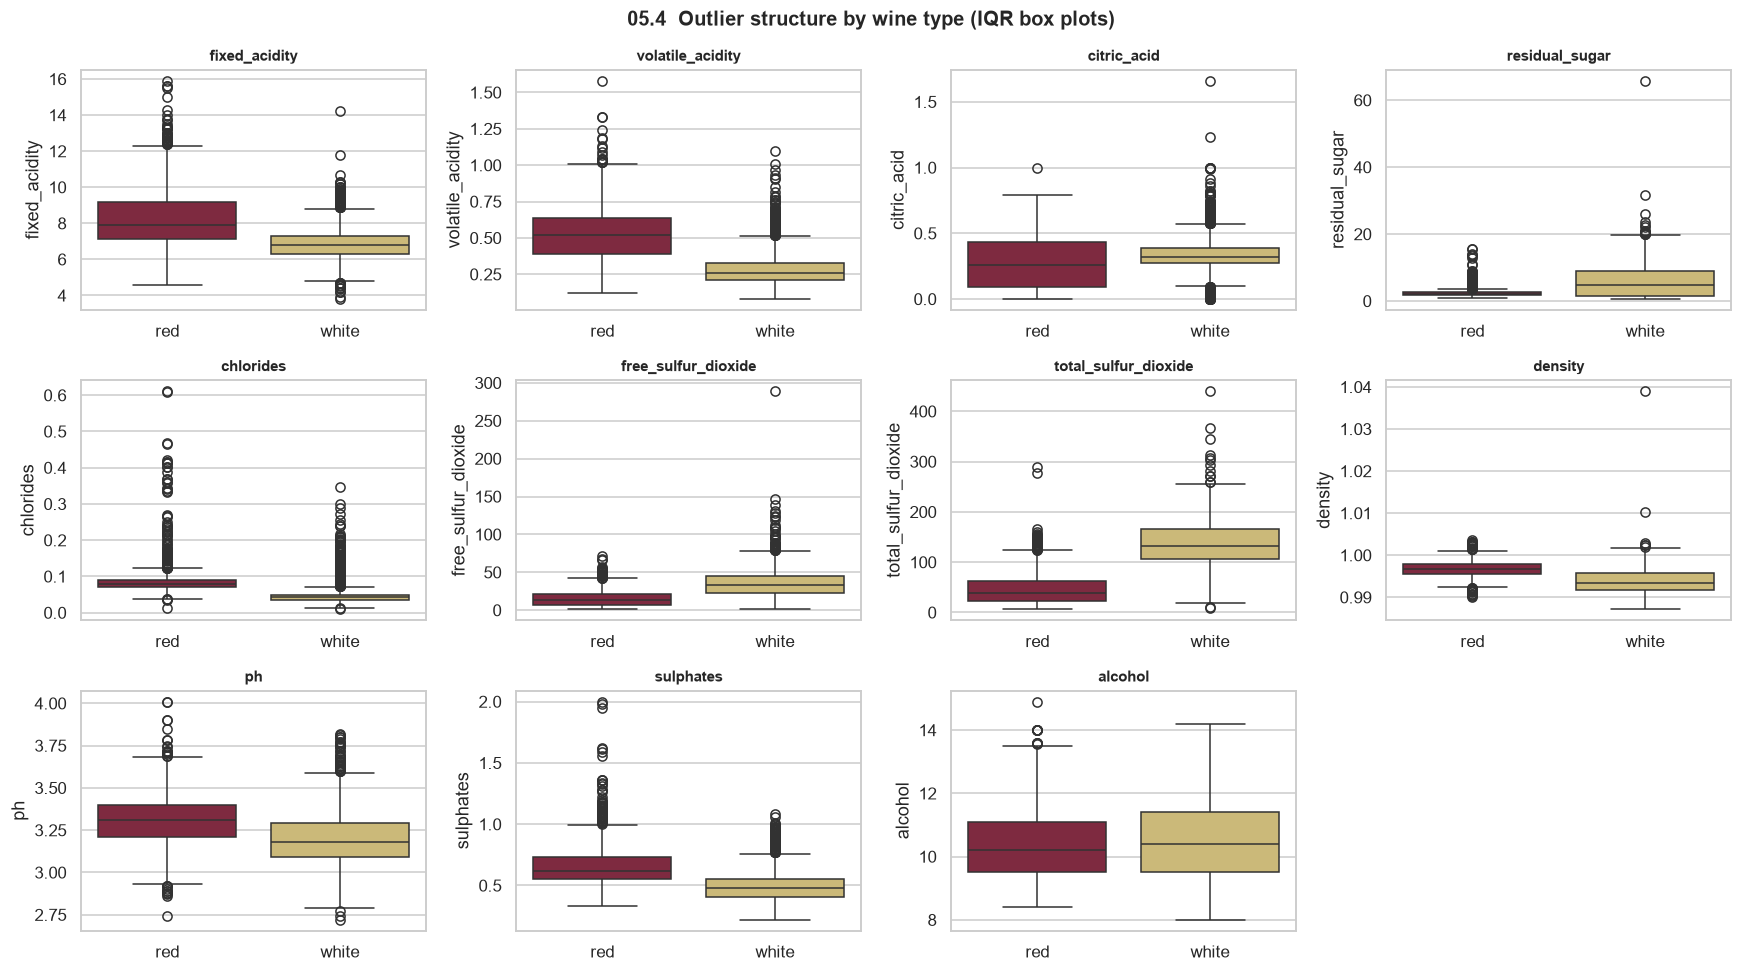

In [13]:
plot_cols = [c for c in numeric_cols if c != "quality"]
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, col in zip(axes.ravel(), plot_cols):
    sns.boxplot(data=df_clean, x="wine_type", y=col, ax=ax,
                hue="wine_type", palette={"red": RED, "white": WHITE}, legend=False)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
for ax in axes.ravel()[len(plot_cols):]:
    ax.axis("off")
fig.suptitle("05.4  Outlier structure by wine type (IQR box plots)", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_outliers_boxplots.png", bbox_inches="tight")
plt.show()

### 05.5 Data types & final clean-data contract

In [14]:
df_clean["wine_type"] = df_clean["wine_type"].astype("category")
df_clean["quality"] = df_clean["quality"].astype(int)

print(df_clean.dtypes)
print(f"\nCLEAN DATASET: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"memory: {df_clean.memory_usage(deep=True).sum()/1e6:.2f} MB")
print("\nContract for everything downstream:")
print("  • no missing values   • no duplicates   • no impossible values")
print("  • outliers retained and documented      • wine_type is categorical")

fixed_acidity            float64
volatile_acidity         float64
citric_acid              float64
residual_sugar           float64
chlorides                float64
free_sulfur_dioxide      float64
total_sulfur_dioxide     float64
density                  float64
ph                       float64
sulphates                float64
alcohol                  float64
quality                    int64
wine_type               category
dtype: object

CLEAN DATASET: 5,320 rows x 13 columns
memory: 0.52 MB

Contract for everything downstream:
  • no missing values   • no duplicates   • no impossible values
  • outliers retained and documented      • wine_type is categorical


---
## 06. Exploratory Data Analysis (EDA)

> **🔎 Highlights**
> - **What:** four passes over the data — target distribution, feature distributions, correlations, red vs white.
> - **Why:** EDA sets your expectations. If `alcohol` is the strongest correlate here, a model that ranks it low later is a bug, not an insight.
> - **Look for:** (1) quality is heavily **imbalanced** — scores 5–6 are ~77 % of all wines; (2) `alcohol` is the top positive correlate (**r ≈ +0.47**), `density` and `volatile_acidity` the top negatives; (3) `free ↔ total SO₂` (**r ≈ +0.72**) and `density ↔ alcohol` (**r ≈ −0.67**) are strongly collinear, which will destabilise linear coefficients.

### 06.1 Quality distribution

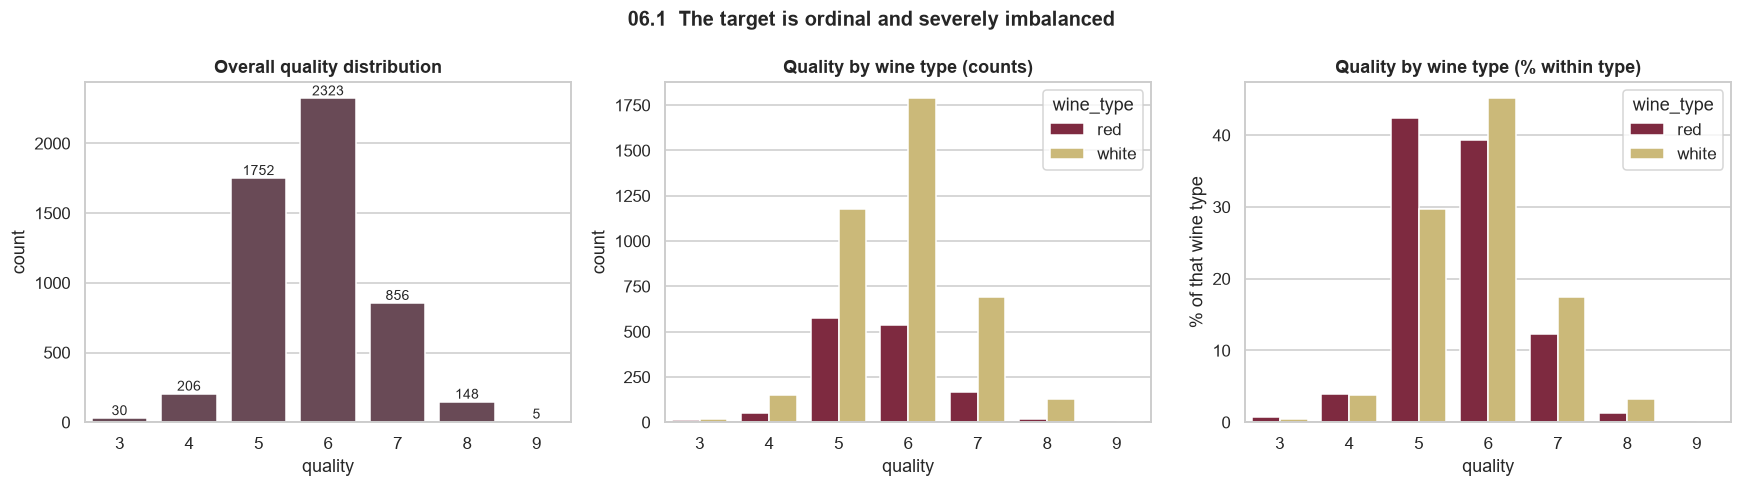

Scores 5 and 6 alone account for 76.6% of all wines.
Scores 3, 4, 8, 9 combined: 7.3%
→ Consequence: a model can look 'accurate' by always guessing 6. Our baseline in §11 makes
  that trap explicit, and RMSE is chosen precisely because it punishes the ignored extremes.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.countplot(data=df_clean, x="quality", ax=axes[0], color="#6E4555")
axes[0].set_title("Overall quality distribution")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=9)

sns.countplot(data=df_clean, x="quality", hue="wine_type", ax=axes[1],
              palette={"red": RED, "white": WHITE})
axes[1].set_title("Quality by wine type (counts)")

prop = (df_clean.groupby("wine_type", observed=True)["quality"]
        .value_counts(normalize=True).mul(100).rename("pct").reset_index())
sns.barplot(data=prop, x="quality", y="pct", hue="wine_type", ax=axes[2],
            palette={"red": RED, "white": WHITE})
axes[2].set_title("Quality by wine type (% within type)")
axes[2].set_ylabel("% of that wine type")

fig.suptitle("06.1  The target is ordinal and severely imbalanced", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_quality_distribution.png", bbox_inches="tight")
plt.show()

share_56 = 100 * df_clean["quality"].isin([5, 6]).mean()
print(f"Scores 5 and 6 alone account for {share_56:.1f}% of all wines.")
print(f"Scores 3, 4, 8, 9 combined: {100 - share_56 - 100*df_clean['quality'].eq(7).mean():.1f}%")
print("→ Consequence: a model can look 'accurate' by always guessing 6. Our baseline in §11 makes")
print("  that trap explicit, and RMSE is chosen precisely because it punishes the ignored extremes.")

### 06.2 Feature distributions

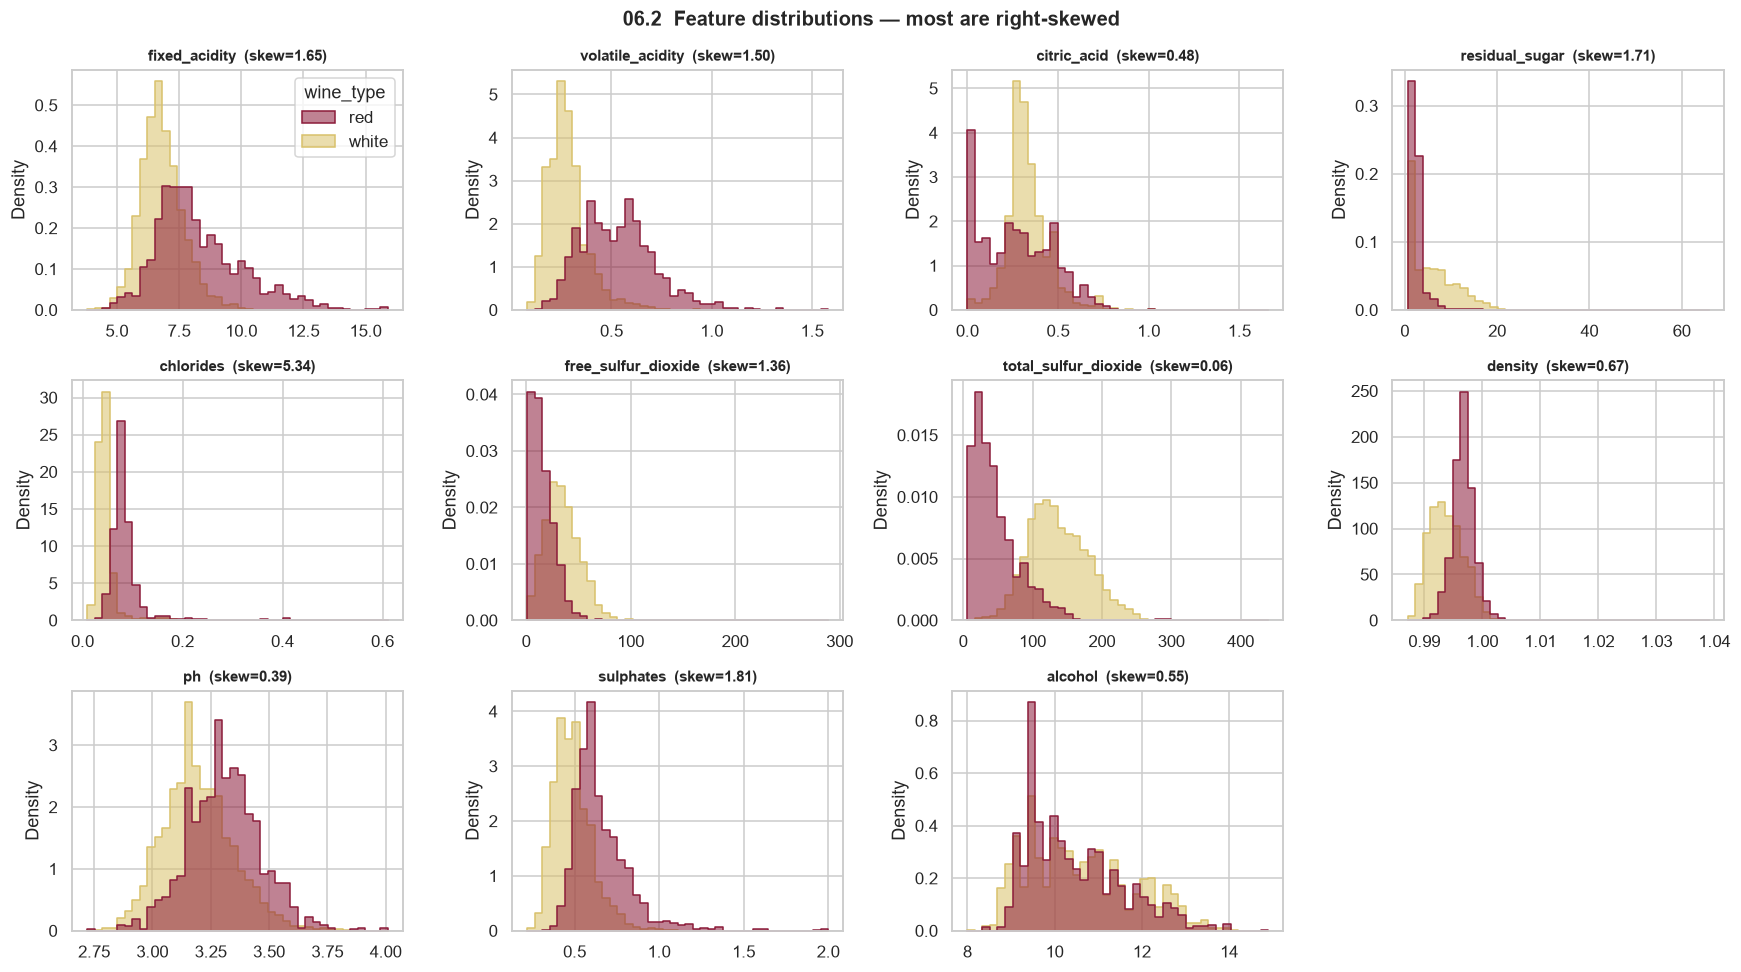

Most skewed features (|skew| > 1 ⇒ strongly non-normal):
chlorides             5.3400
sulphates             1.8100
residual_sugar        1.7100
fixed_acidity         1.6500
volatile_acidity      1.5000
free_sulfur_dioxide   1.3600
dtype: float64

→ Linear regression assumes roughly symmetric residuals, not symmetric features, so we do
  not blindly log-transform. Tree models are invariant to monotone transforms entirely.


In [16]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, col in zip(axes.ravel(), plot_cols):
    sns.histplot(data=df_clean, x=col, hue="wine_type", ax=ax, bins=40,
                 palette={"red": RED, "white": WHITE}, alpha=0.55,
                 element="step", stat="density", common_norm=False, legend=(ax is axes[0, 0]))
    ax.set_title(f"{col}  (skew={df_clean[col].skew():.2f})", fontsize=10)
    ax.set_xlabel("")
for ax in axes.ravel()[len(plot_cols):]:
    ax.axis("off")
fig.suptitle("06.2  Feature distributions — most are right-skewed", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_feature_distributions.png", bbox_inches="tight")
plt.show()

skews = df_clean[plot_cols].skew().sort_values(ascending=False)
print("Most skewed features (|skew| > 1 ⇒ strongly non-normal):")
print(skews[skews.abs() > 1].round(2))
print("\n→ Linear regression assumes roughly symmetric residuals, not symmetric features, so we do")
print("  not blindly log-transform. Tree models are invariant to monotone transforms entirely.")

### 06.3 Correlations

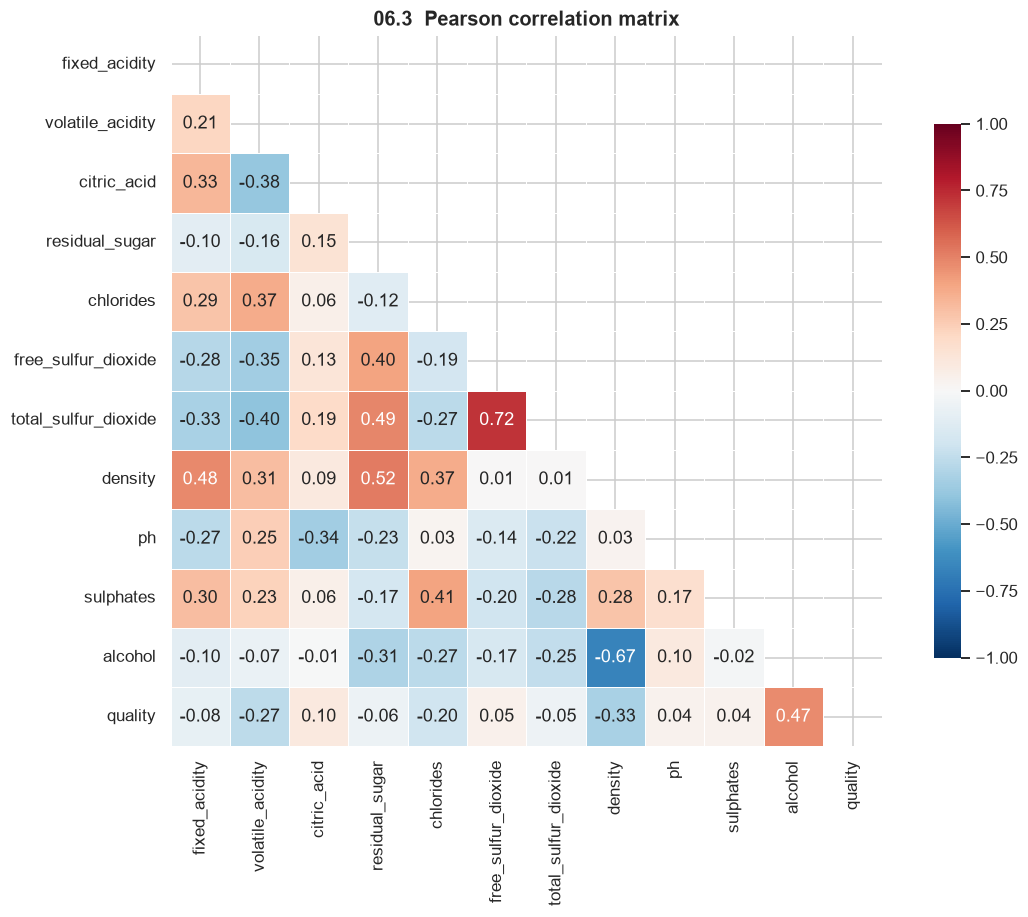

In [17]:
corr = df_clean[numeric_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 8.5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={"shrink": 0.75}, ax=ax)
ax.set_title("06.3  Pearson correlation matrix", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_correlation_heatmap.png", bbox_inches="tight")
plt.show()

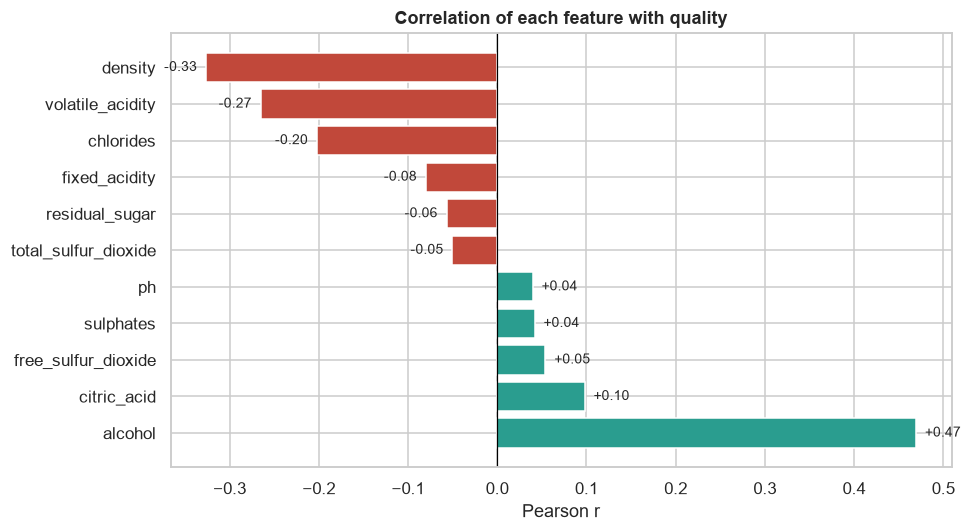

Strongest signals:
alcohol               0.4690
citric_acid           0.0980
free_sulfur_dioxide   0.0540
Name: quality, dtype: float64
chlorides          -0.2020
volatile_acidity   -0.2650
density            -0.3260
Name: quality, dtype: float64

Feature pairs with |r| > 0.5 — collinearity that will destabilise linear coefficients:
                  a                    b       r
free_sulfur_dioxide total_sulfur_dioxide  0.7200
            alcohol              density -0.6680
            density       residual_sugar  0.5210


In [18]:
target_corr = corr["quality"].drop("quality").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#2A9D8F" if v > 0 else "#C1483A" for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Correlation of each feature with quality", fontsize=12, fontweight="bold")
ax.set_xlabel("Pearson r")
for i, v in enumerate(target_corr.values):
    ax.text(v + (0.01 if v > 0 else -0.01), i, f"{v:+.2f}",
            va="center", ha="left" if v > 0 else "right", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "06_target_correlation.png", bbox_inches="tight")
plt.show()

print("Strongest signals:")
print(target_corr.head(3).round(3))
print(target_corr.tail(3).round(3))

# multicollinearity watch-list
pairs = (corr.where(~np.eye(len(corr), dtype=bool))
         .stack().rename("r").reset_index()
         .rename(columns={"level_0": "a", "level_1": "b"}))
pairs = pairs[pairs.a < pairs.b]
print("\nFeature pairs with |r| > 0.5 — collinearity that will destabilise linear coefficients:")
print(pairs.reindex(pairs.r.abs().sort_values(ascending=False).index)
      .query("abs(r) > 0.5").round(3).to_string(index=False))

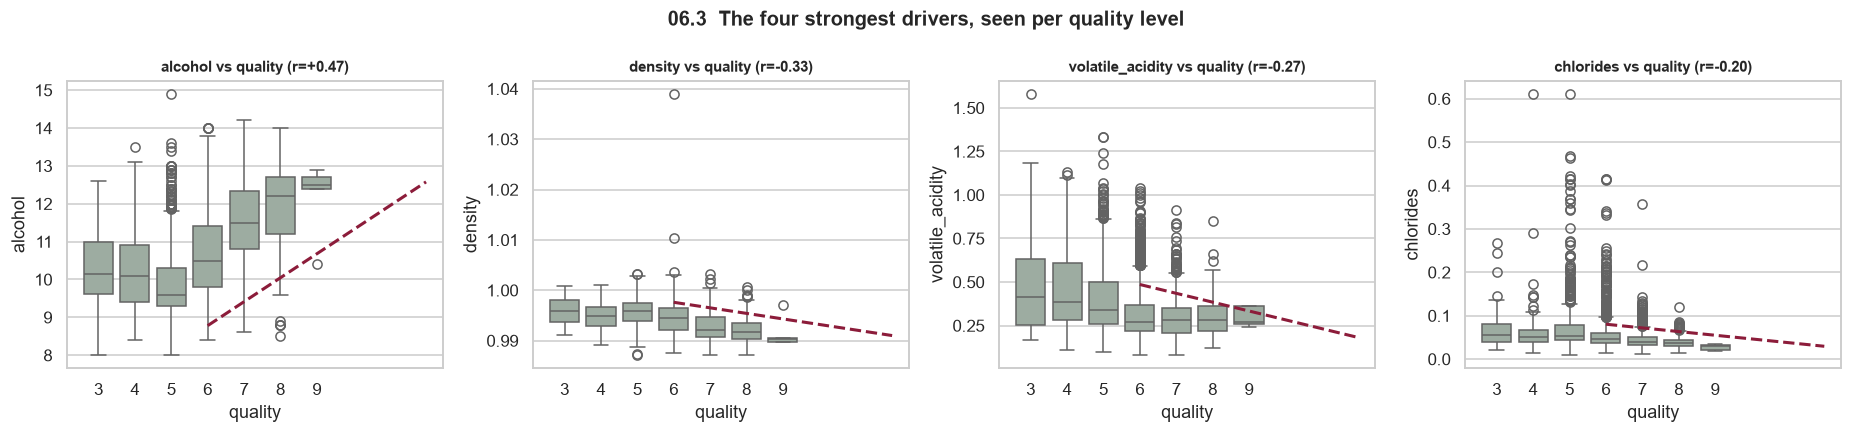

Alcohol rises monotonically with quality; volatile acidity falls. These two do most of the work.


In [19]:
top_feats = target_corr.abs().sort_values(ascending=False).head(4).index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, col in zip(axes, top_feats):
    sns.boxplot(data=df_clean, x="quality", y=col, ax=ax, color="#9BAFA0")
    sns.regplot(data=df_clean, x="quality", y=col, scatter=False, ax=ax,
                color="#8C1C3A", ci=None, line_kws={"lw": 2, "ls": "--"})
    ax.set_title(f"{col} vs quality (r={target_corr[col]:+.2f})", fontsize=10)
fig.suptitle("06.3  The four strongest drivers, seen per quality level",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_top_features_vs_quality.png", bbox_inches="tight")
plt.show()
print("Alcohol rises monotonically with quality; volatile acidity falls. These two do most of the work.")

### 06.4 Red vs white comparison

In [20]:
comparison = (df_clean.groupby("wine_type", observed=True)[plot_cols + ["quality"]]
              .mean().T)
comparison["difference"] = comparison["white"] - comparison["red"]
comparison["pct_diff"] = (100 * comparison["difference"] / comparison["red"]).round(1)

# Welch t-test: are the two styles chemically distinguishable?
pvals = {}
for col in plot_cols + ["quality"]:
    a = df_clean.loc[df_clean.wine_type == "red", col]
    b = df_clean.loc[df_clean.wine_type == "white", col]
    pvals[col] = stats.ttest_ind(a, b, equal_var=False).pvalue
comparison["p_value"] = pd.Series(pvals)
comparison["significant"] = np.where(comparison.p_value < 0.001, "*** p<0.001", "n.s.")

display(comparison.round(4))

print(f"Mean quality — red: {df_clean.query('wine_type==\"red\"').quality.mean():.2f}  |  "
      f"white: {df_clean.query('wine_type==\"white\"').quality.mean():.2f}")
print("\nWhites carry far more residual sugar and SO₂; reds carry more volatile acidity and sulphates.")
print("The two styles are chemically distinct → wine_type earns its place as a feature (§07).")

wine_type,red,white,difference,pct_diff,p_value,significant
fixed_acidity,8.3106,6.8393,-1.4712,-17.7000,0.0000,*** p<0.001
volatile_acidity,0.5295,0.2805,-0.2489,-47.0000,0.0000,*** p<0.001
citric_acid,0.2723,0.3343,0.0620,22.8000,0.0000,*** p<0.001
residual_sugar,2.5234,5.9148,3.3914,134.4000,0.0000,*** p<0.001
chlorides,0.0881,0.0459,-0.0422,-47.9000,0.0000,*** p<0.001
free_sulfur_dioxide,15.8933,34.8892,18.9959,119.5000,0.0000,*** p<0.001
total_sulfur_dioxide,46.8260,137.1935,90.3675,193.0000,0.0000,*** p<0.001
density,0.9967,0.9938,-0.0029,-0.3000,0.0000,*** p<0.001
ph,3.3098,3.1955,-0.1143,-3.5000,0.0000,*** p<0.001
sulphates,0.6587,0.4904,-0.1684,-25.6000,0.0000,*** p<0.001


Mean quality — red: 5.62  |  white: 5.85

Whites carry far more residual sugar and SO₂; reds carry more volatile acidity and sulphates.
The two styles are chemically distinct → wine_type earns its place as a feature (§07).


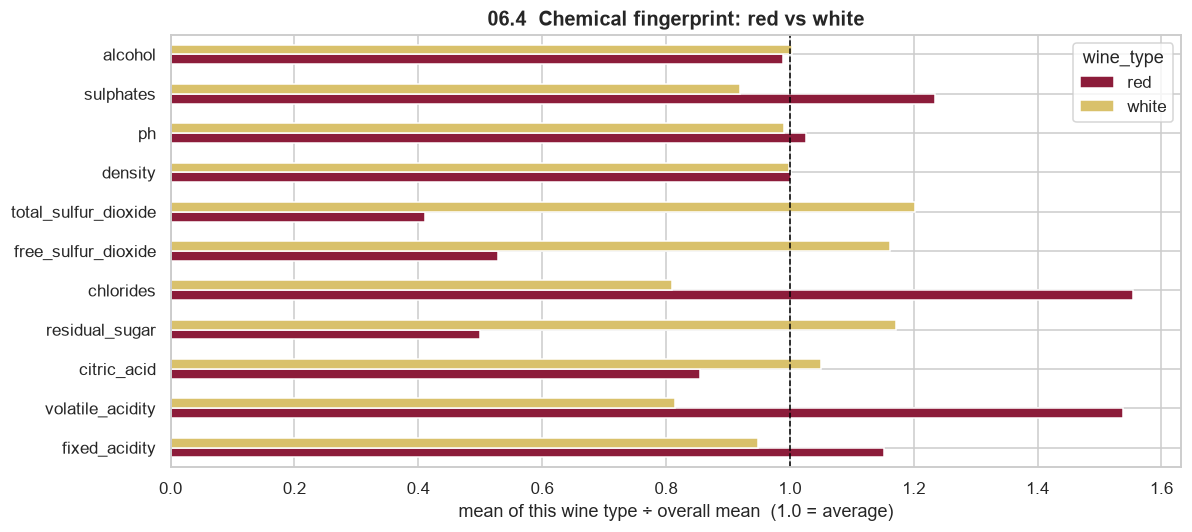

In [21]:
fig, ax = plt.subplots(figsize=(11, 5))
scaled_means = (df_clean.groupby("wine_type", observed=True)[plot_cols].mean()
                / df_clean[plot_cols].mean())
scaled_means.T.plot(kind="barh", ax=ax, color={"red": RED, "white": WHITE})
ax.axvline(1, color="black", ls="--", lw=1)
ax.set_xlabel("mean of this wine type ÷ overall mean  (1.0 = average)")
ax.set_title("06.4  Chemical fingerprint: red vs white", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_red_vs_white.png", bbox_inches="tight")
plt.show()

---
## 07. Feature Engineering & Target Definition

> **🔎 Highlights**
> - **What:** encode wine type, derive six chemistry-informed ratio features, and lock the target definitions.
> - **Why:** ratios encode *oenological knowledge* the model cannot invent from raw columns — e.g. the free/total SO₂ fraction is what actually protects wine, not either number alone.
> - **Look for:** the engineering lives in **`wine_features.py`**, imported by both this notebook and the Streamlit app. One definition, zero training/serving skew — the single most common bug in deployed ML.

**Engineered features and their rationale**

| Feature | Formula | Why a winemaker cares |
|---|---|---|
| `is_red` | 1 if red | Encodes the style split shown in 06.4. |
| `total_acidity` | fixed + volatile + citric | Overall acid load, the perceived "tartness". |
| `free_so2_ratio` | free ÷ total SO₂ | The *active* antimicrobial fraction; bound SO₂ does nothing. |
| `bound_so2` | total − free | Purely bound SO₂; tracks oxidation history. |
| `sugar_to_alcohol` | residual sugar ÷ alcohol | Sweetness balance — sugar only reads as sweet relative to body. |
| `acidity_to_alcohol` | total acidity ÷ alcohol | Structural balance; the classic "backbone vs warmth" trade-off. |
| `sulphates_x_alcohol` | sulphates × alcohol | Interaction: the two known preservative/quality levers together. |

**Target definitions**
- `quality` — integer 3–9 → **regression target `y`**.
- `quality_band` — `low` (≤4) / `medium` (5–6) / `high` (≥7) → used only to **stratify** the split.
- `is_premium` — `quality >= 7` → reported as a secondary business view and badged in the app.

In [22]:
%%writefile wine_features.py
"""Shared feature engineering for the wine-quality project.

Imported by BOTH the training notebook and the Streamlit app so that a wine is
transformed identically at training time and at prediction time.
"""
from __future__ import annotations

import numpy as np
import pandas as pd

RAW_FEATURES = [
    "fixed_acidity",
    "volatile_acidity",
    "citric_acid",
    "residual_sugar",
    "chlorides",
    "free_sulfur_dioxide",
    "total_sulfur_dioxide",
    "density",
    "ph",
    "sulphates",
    "alcohol",
]

ENGINEERED_FEATURES = [
    "is_red",
    "total_acidity",
    "free_so2_ratio",
    "bound_so2",
    "sugar_to_alcohol",
    "acidity_to_alcohol",
    "sulphates_x_alcohol",
]

MODEL_FEATURES = RAW_FEATURES + ENGINEERED_FEATURES

QUALITY_BANDS = {"low": "≤ 4", "medium": "5 – 6", "high": "≥ 7"}


def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    """Return a copy of `data` with the engineered columns added.

    `data` must contain RAW_FEATURES plus either `wine_type` ('red'/'white')
    or an existing `is_red` column.
    """
    out = data.copy()
    out.columns = [c.strip().lower().replace(" ", "_") for c in out.columns]

    if "is_red" not in out.columns:
        out["is_red"] = (out["wine_type"].astype(str).str.lower() == "red").astype(int)

    eps = 1e-9
    out["total_acidity"] = out.fixed_acidity + out.volatile_acidity + out.citric_acid
    out["free_so2_ratio"] = out.free_sulfur_dioxide / (out.total_sulfur_dioxide + eps)
    out["bound_so2"] = (out.total_sulfur_dioxide - out.free_sulfur_dioxide).clip(lower=0)
    out["sugar_to_alcohol"] = out.residual_sugar / (out.alcohol + eps)
    out["acidity_to_alcohol"] = out.total_acidity / (out.alcohol + eps)
    out["sulphates_x_alcohol"] = out.sulphates * out.alcohol

    return out.replace([np.inf, -np.inf], np.nan)


def band_of(score: float) -> str:
    """Map a numeric quality score onto the low/medium/high band."""
    if score <= 4:
        return "low"
    if score <= 6:
        return "medium"
    return "high"

Overwriting wine_features.py


In [23]:
import importlib
import wine_features
importlib.reload(wine_features)
from wine_features import MODEL_FEATURES, RAW_FEATURES, ENGINEERED_FEATURES, band_of, engineer_features

data = engineer_features(df_clean)
data["quality_band"] = data["quality"].apply(band_of)
data["is_premium"] = (data["quality"] >= 7).astype(int)

X = data[MODEL_FEATURES].copy()
y = data["quality"].astype(float).copy()

print(f"Feature matrix X : {X.shape}   ({len(RAW_FEATURES)} raw + {len(ENGINEERED_FEATURES)} engineered)")
print(f"Target vector  y : {y.shape}   mean={y.mean():.3f}  std={y.std():.3f}")
print(f"NaNs in X: {int(X.isna().sum().sum())}")

print("\nQuality bands:")
print(data["quality_band"].value_counts().reindex(["low", "medium", "high"]))
print(f"\nPremium wines (quality>=7): {data.is_premium.sum():,} ({100*data.is_premium.mean():.1f}%)")

display(X.head())

Feature matrix X : (5320, 18)   (11 raw + 7 engineered)
Target vector  y : (5320,)   mean=5.796  std=0.880
NaNs in X: 0

Quality bands:
quality_band
low        236
medium    4075
high      1009
Name: count, dtype: int64

Premium wines (quality>=7): 1,009 (19.0%)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,is_red,total_acidity,free_so2_ratio,bound_so2,sugar_to_alcohol,acidity_to_alcohol,sulphates_x_alcohol
0,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,1,8.1000,0.3235,23.0000,0.2021,0.8617,5.2640
1,7.8000,0.8800,0.0000,2.6000,0.0980,25.0000,67.0000,0.9968,3.2000,0.6800,9.8000,1,8.6800,0.3731,42.0000,0.2653,0.8857,6.6640
2,7.8000,0.7600,0.0400,2.3000,0.0920,15.0000,54.0000,0.9970,3.2600,0.6500,9.8000,1,8.6000,0.2778,39.0000,0.2347,0.8776,6.3700
3,11.2000,0.2800,0.5600,1.9000,0.0750,17.0000,60.0000,0.9980,3.1600,0.5800,9.8000,1,12.0400,0.2833,43.0000,0.1939,1.2286,5.6840
4,7.4000,0.6600,0.0000,1.8000,0.0750,13.0000,40.0000,0.9978,3.5100,0.5600,9.4000,1,8.0600,0.3250,27.0000,0.1915,0.8574,5.2640


In [24]:
eng_corr = (data[ENGINEERED_FEATURES + ["quality"]].corr()["quality"]
            .drop("quality").sort_values(key=abs, ascending=False))
print("Did the engineered features earn their place? (correlation with quality)")
print(eng_corr.round(3))
all_corr = (data[MODEL_FEATURES + ["quality"]].corr()["quality"].drop("quality")
            .sort_values(key=abs, ascending=False))
rank_of_best_eng = list(all_corr.index).index(eng_corr.abs().idxmax()) + 1

print(f"\nBest raw feature        : {target_corr.abs().idxmax()} (|r| = {target_corr.abs().max():.3f})")
print(f"Best engineered feature : {eng_corr.abs().idxmax()} (|r| = {eng_corr.abs().max():.3f}) "
      f"— rank {rank_of_best_eng} of {len(all_corr)} overall")
print("\n→ No engineered feature out-correlates `alcohol`, but `acidity_to_alcohol` lands in the top")
print("  handful, so the balance idea carries signal the raw columns do not express on their own.")
print("  Linear correlation also UNDERSTATES their value: ratios exist to help tree models split on")
print("  interactions. §12.4 measures the real contribution by ablation, and §14 by importance.")

Did the engineered features earn their place? (correlation with quality)
acidity_to_alcohol    -0.3060
sulphates_x_alcohol    0.2120
free_so2_ratio         0.1240
is_red                -0.1150
sugar_to_alcohol      -0.1000
total_acidity         -0.0960
bound_so2             -0.0840
Name: quality, dtype: float64

Best raw feature        : alcohol (|r| = 0.469)
Best engineered feature : acidity_to_alcohol (|r| = 0.306) — rank 3 of 18 overall

→ No engineered feature out-correlates `alcohol`, but `acidity_to_alcohol` lands in the top
  handful, so the balance idea carries signal the raw columns do not express on their own.
  Linear correlation also UNDERSTATES their value: ratios exist to help tree models split on
  interactions. §12.4 measures the real contribution by ablation, and §14 by importance.


---
## 08. Train/Test Split

> **🔎 Highlights**
> - **What:** an 80/20 split, **stratified on `quality_band`**, with a fixed seed.
> - **Why:** random splitting can leave only a handful of the rare `low` wines in the test set; stratification keeps the rarest band proportionally represented so the test score is stable.
> - **Look for:** the before/after proportion table — train and test band shares should match to within a fraction of a percent. **The test set is now sealed** and is not touched again until section 13.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=data["quality_band"],
)

# keep the row-aligned metadata for later analysis
meta_train = data.loc[X_train.index, ["wine_type", "quality_band", "is_premium"]]
meta_test = data.loc[X_test.index, ["wine_type", "quality_band", "is_premium"]]

print(f"train: {X_train.shape[0]:,} rows  ({100*len(X_train)/len(X):.0f}%)")
print(f"test : {X_test.shape[0]:,} rows  ({100*len(X_test)/len(X):.0f}%)")

check = pd.DataFrame({
    "full_%": 100 * data.quality_band.value_counts(normalize=True),
    "train_%": 100 * meta_train.quality_band.value_counts(normalize=True),
    "test_%": 100 * meta_test.quality_band.value_counts(normalize=True),
}).reindex(["low", "medium", "high"]).round(2)
display(check)

print(f"mean quality — train {y_train.mean():.3f} | test {y_test.mean():.3f}")
print(f"red share    — train {100*(meta_train.wine_type=='red').mean():.1f}% | "
      f"test {100*(meta_test.wine_type=='red').mean():.1f}%")
print("\n🔒 The test set is now sealed. No fitting, no scaling, no tuning touches it until §13.")

train: 4,256 rows  (80%)
test : 1,064 rows  (20%)


,full_%,train_%,test_%
quality_band,,,
low,4.4400,4.4400,4.4200
medium,76.6000,76.6000,76.6000
high,18.9700,18.9600,18.9800


mean quality — train 5.796 | test 5.795
red share    — train 25.1% | test 27.2%

🔒 The test set is now sealed. No fitting, no scaling, no tuning touches it until §13.


---
## 09. Feature Scaling

> **🔎 Highlights**
> - **What:** `StandardScaler` (z-scores) **fit on the training set only**, then applied to test.
> - **Why:** KNN and SVR measure distance, so `total_sulfur_dioxide` (range ≈ 440) would otherwise drown out `density` (range ≈ 0.05). Fitting the scaler on all data leaks test statistics into training.
> - **Look for:** train means ≈ 0 and stds ≈ 1; test means are *close to* but not exactly 0 — that small gap is the honest evidence that the test set stayed unseen.

In [26]:
scaler = StandardScaler().fit(X_train)          # ← fit on TRAIN only

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

check = pd.DataFrame({
    "raw_mean": X_train.mean(),
    "raw_std": X_train.std(),
    "scaled_train_mean": X_train_scaled.mean(),
    "scaled_train_std": X_train_scaled.std(),
    "scaled_test_mean": X_test_scaled.mean(),
    "scaled_test_std": X_test_scaled.std(),
}).round(3)
display(check)

print("Scaling matters for: KNN, SVR, PCA, K-Means, and the interpretability of linear coefficients.")
print("It is irrelevant for: Random Forest, XGBoost (split points are scale-invariant).")
print("\n⚠️  In §11 onward every model is wrapped in a Pipeline(scaler → model), so cross-validation")
print("    re-fits the scaler inside each fold. That is the leak-proof way to do this.")

,raw_mean,raw_std,scaled_train_mean,scaled_train_std,scaled_test_mean,scaled_test_std
fixed_acidity,7.2150,1.3090,0.0000,1.0000,0.0000,1.0390
volatile_acidity,0.3440,0.1680,0.0000,1.0000,-0.0040,1.0060
citric_acid,0.3180,0.1450,-0.0000,1.0000,0.0240,1.0690
residual_sugar,5.0490,4.5030,0.0000,1.0000,-0.0010,0.9980
chlorides,0.0570,0.0380,-0.0000,1.0000,-0.0180,0.8580
free_sulfur_dioxide,30.0400,17.8210,-0.0000,1.0000,-0.0010,0.9960
total_sulfur_dioxide,114.1780,56.4110,-0.0000,1.0000,-0.0060,1.0320
density,0.9950,0.0030,-0.0000,1.0000,0.0180,0.9810
ph,3.2230,0.1600,0.0000,1.0000,0.0560,1.0190
sulphates,0.5330,0.1500,-0.0000,1.0000,0.0150,0.9770


Scaling matters for: KNN, SVR, PCA, K-Means, and the interpretability of linear coefficients.
It is irrelevant for: Random Forest, XGBoost (split points are scale-invariant).

⚠️  In §11 onward every model is wrapped in a Pipeline(scaler → model), so cross-validation
    re-fits the scaler inside each fold. That is the leak-proof way to do this.


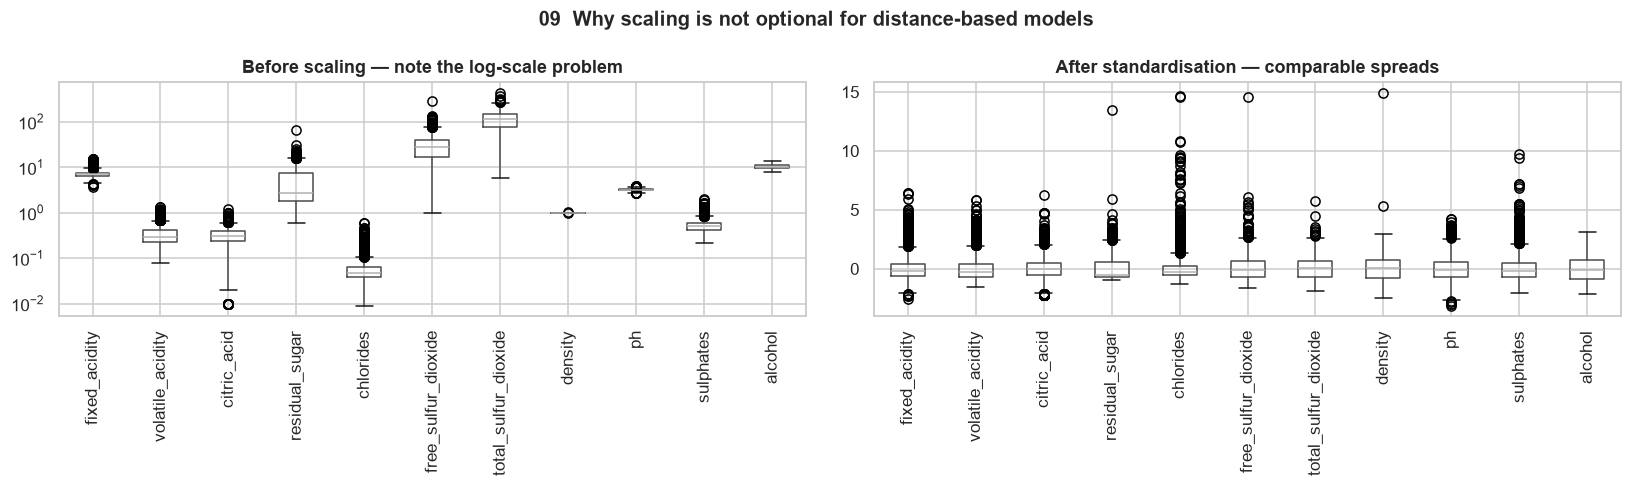

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
X_train[plot_cols].boxplot(ax=axes[0], rot=90)
axes[0].set_title("Before scaling — note the log-scale problem")
axes[0].set_yscale("log")
X_train_scaled[plot_cols].boxplot(ax=axes[1], rot=90)
axes[1].set_title("After standardisation — comparable spreads")
fig.suptitle("09  Why scaling is not optional for distance-based models",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "09_scaling_effect.png", bbox_inches="tight")
plt.show()

---
## 10. Unsupervised Learning

> **🔎 Highlights**
> - **What:** ignore the target entirely and ask what natural groups the chemistry forms — K-Means (with elbow + silhouette to choose *k*), hierarchical clustering, and PCA.
> - **Why:** if clusters aligned with quality, a simple rule could replace the model. Spoiler: they align with **red vs white**, not with quality.
> - **Look for:** k = 2 wins the silhouette score and reproduces the red/white split with **~99 % purity**, while mean quality differs by only ~0.24 points between clusters. PCA needs **8 of 18 components** for 90 % of the variance — the signal is genuinely multivariate, which justifies the supervised models that follow.

### 10.1 Choosing K — elbow and silhouette

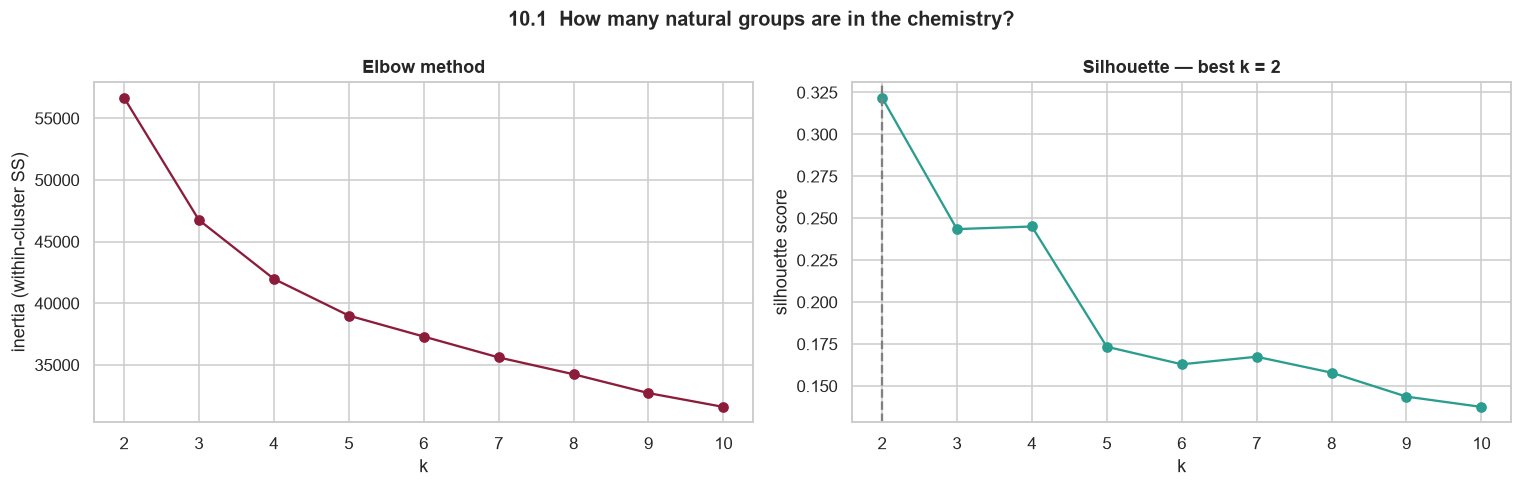

 k     inertia  silhouette
 2 56,683.6000      0.3219
 3 46,756.3000      0.2435
 4 41,981.6000      0.2451
 5 39,000.9000      0.1734
 6 37,301.8000      0.1629
 7 35,609.3000      0.1674
 8 34,243.3000      0.1579
 9 32,715.4000      0.1437
10 31,592.4000      0.1375

Best k by silhouette: 2


In [28]:
Xu = X_train_scaled.values           # unsupervised input: scaled training features, no y

k_range = range(2, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xu)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(Xu, km.labels_, sample_size=3000,
                                        random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(list(k_range), inertias, "o-", color="#8C1C3A")
axes[0].set(xlabel="k", ylabel="inertia (within-cluster SS)", title="Elbow method")
axes[1].plot(list(k_range), silhouettes, "o-", color="#2A9D8F")
best_k = list(k_range)[int(np.argmax(silhouettes))]
axes[1].axvline(best_k, ls="--", color="grey")
axes[1].set(xlabel="k", ylabel="silhouette score", title=f"Silhouette — best k = {best_k}")
fig.suptitle("10.1  How many natural groups are in the chemistry?",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "10_choosing_k.png", bbox_inches="tight")
plt.show()

print(pd.DataFrame({"k": list(k_range),
                    "inertia": np.round(inertias, 1),
                    "silhouette": np.round(silhouettes, 4)}).to_string(index=False))
print(f"\nBest k by silhouette: {best_k}")

### 10.2 K-Means — what do the clusters actually represent?

In [29]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit(Xu)
clusters = pd.Series(kmeans.labels_, index=X_train.index, name="cluster")

profile = pd.crosstab(clusters, meta_train.wine_type, normalize="index").mul(100).round(1)
profile.columns = [f"% {c}" for c in profile.columns]
profile["n"] = clusters.value_counts().sort_index()
profile["mean_quality"] = y_train.groupby(clusters).mean().round(3)
profile["% premium"] = (meta_train.is_premium.groupby(clusters).mean() * 100).round(1)
display(profile)

purity = pd.crosstab(clusters, meta_train.wine_type).max(axis=1).sum() / len(clusters)
print(f"Cluster ↔ wine-type purity: {100*purity:.1f}%")
print(f"Spread of mean quality across clusters: {profile.mean_quality.max()-profile.mean_quality.min():.2f} points")
print("\nINTERPRETATION: unsupervised structure recovers the PRODUCT LINE, not the quality grade.")
print("Quality is a subtle, within-style effect — which is exactly why we need supervised learning.")

,% red,% white,n,mean_quality,% premium
cluster,,,,,
0,0.5000,99.5000,3197,5.8550,20.8000
1,99.5000,0.5000,1059,5.6180,13.4000


Cluster ↔ wine-type purity: 99.5%
Spread of mean quality across clusters: 0.24 points

INTERPRETATION: unsupervised structure recovers the PRODUCT LINE, not the quality grade.
Quality is a subtle, within-style effect — which is exactly why we need supervised learning.


In [30]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=X.columns, index=[f"cluster {i}" for i in range(best_k)],
).T
centroids["abs_gap"] = (centroids.max(axis=1) - centroids.min(axis=1)).abs()
print("Cluster centroids in ORIGINAL units (top separating features):")
display(centroids.sort_values("abs_gap", ascending=False).head(8).round(3))

Cluster centroids in ORIGINAL units (top separating features):


,cluster 0,cluster 1,abs_gap
total_sulfur_dioxide,136.6760,46.2620,90.4140
bound_so2,101.9100,30.4900,71.4200
free_sulfur_dioxide,34.7660,15.7720,18.9940
residual_sugar,5.9060,2.4610,3.4450
total_acidity,7.4520,9.1610,1.7100
sulphates_x_alcohol,5.1940,6.8920,1.6980
fixed_acidity,6.8370,8.3550,1.5180
is_red,0.0050,0.9950,0.9900


### 10.3 Hierarchical clustering

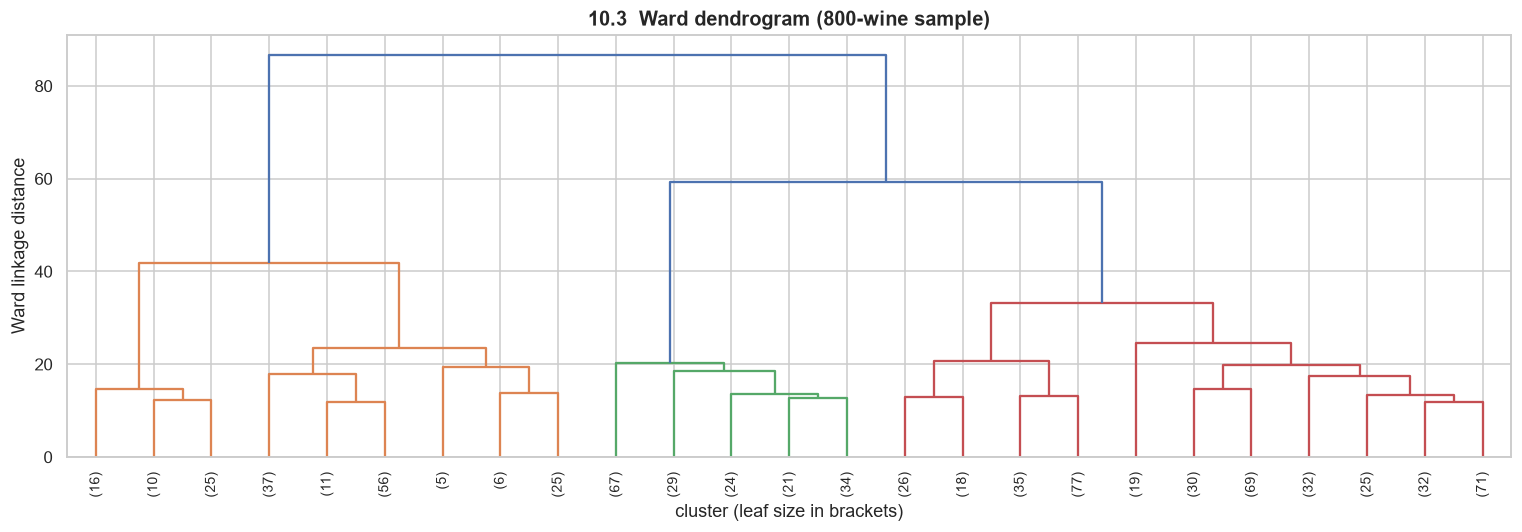

The tallest vertical gap sits above a 2-cluster cut — agreeing with the silhouette result.


In [31]:
# Ward linkage on a random sample — the full 5k×5k distance matrix is unnecessary for a dendrogram.
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(Xu), size=800, replace=False)
Z = linkage(Xu[sample_idx], method="ward")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, truncate_mode="lastp", p=25, leaf_rotation=90, leaf_font_size=9,
           color_threshold=0.55 * Z[:, 2].max(), ax=ax)
ax.set_title("10.3  Ward dendrogram (800-wine sample)", fontsize=13, fontweight="bold")
ax.set_xlabel("cluster (leaf size in brackets)")
ax.set_ylabel("Ward linkage distance")
fig.tight_layout()
fig.savefig(FIG_DIR / "10_dendrogram.png", bbox_inches="tight")
plt.show()

print("The tallest vertical gap sits above a 2-cluster cut — agreeing with the silhouette result.")

In [32]:
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward").fit(Xu)
agg_labels = pd.Series(agg.labels_, index=X_train.index, name="hier")

agreement = pd.crosstab(clusters, agg_labels)
display(agreement)
best_match = agreement.max(axis=1).sum() / len(clusters)
print(f"K-Means vs hierarchical agreement: {100*best_match:.1f}% — two very different algorithms")
print("finding the same structure is strong evidence the red/white split is real, not an artefact.")

hier,0,1
cluster,,
0,3195,2
1,19,1040


K-Means vs hierarchical agreement: 99.5% — two very different algorithms
finding the same structure is strong evidence the red/white split is real, not an artefact.


### 10.4 PCA — dimensionality and visualisation

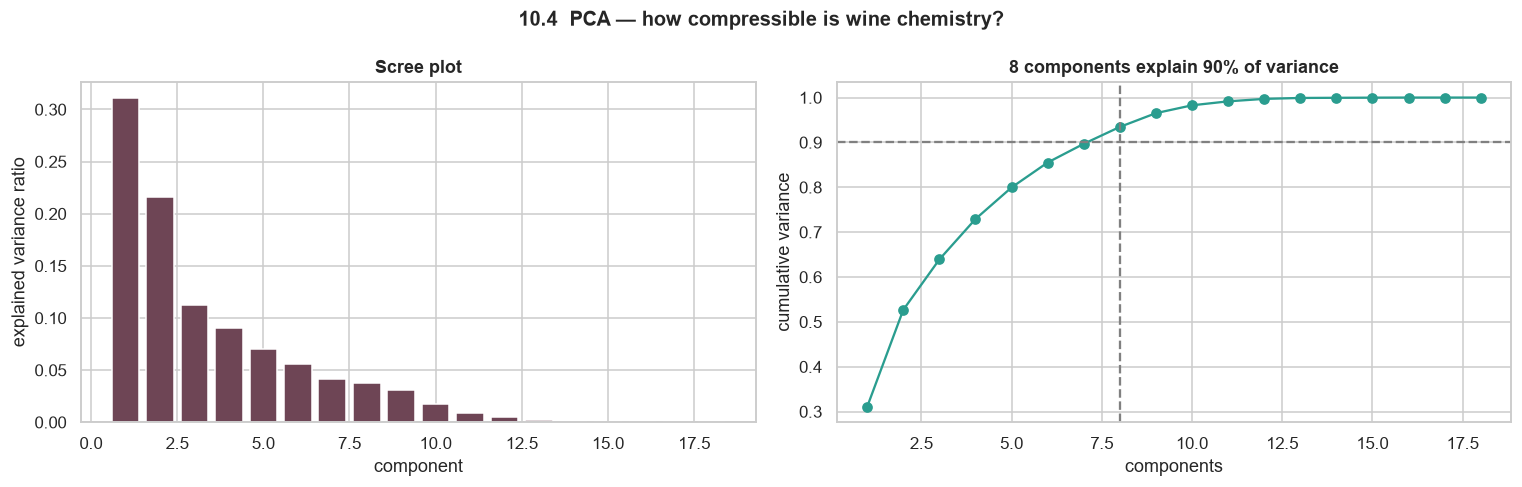

PC1 31.1% | PC2 21.6% | PC1+PC2 52.7%
Components for 90% variance: 8 of 18
→ No cheap 2-D shortcut exists. Keep all features and let the models weigh them.


In [33]:
pca_full = PCA(random_state=RANDOM_STATE).fit(Xu)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
n90 = int(np.argmax(cum >= 0.90) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(range(1, len(evr) + 1), evr, color="#6E4555")
axes[0].set(xlabel="component", ylabel="explained variance ratio", title="Scree plot")
axes[1].plot(range(1, len(cum) + 1), cum, "o-", color="#2A9D8F")
axes[1].axhline(0.90, ls="--", color="grey")
axes[1].axvline(n90, ls="--", color="grey")
axes[1].set(xlabel="components", ylabel="cumulative variance",
            title=f"{n90} components explain 90% of variance")
fig.suptitle("10.4  PCA — how compressible is wine chemistry?", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "10_pca_variance.png", bbox_inches="tight")
plt.show()

print(f"PC1 {evr[0]:.1%} | PC2 {evr[1]:.1%} | PC1+PC2 {cum[1]:.1%}")
print(f"Components for 90% variance: {n90} of {len(evr)}")
print("→ No cheap 2-D shortcut exists. Keep all features and let the models weigh them.")

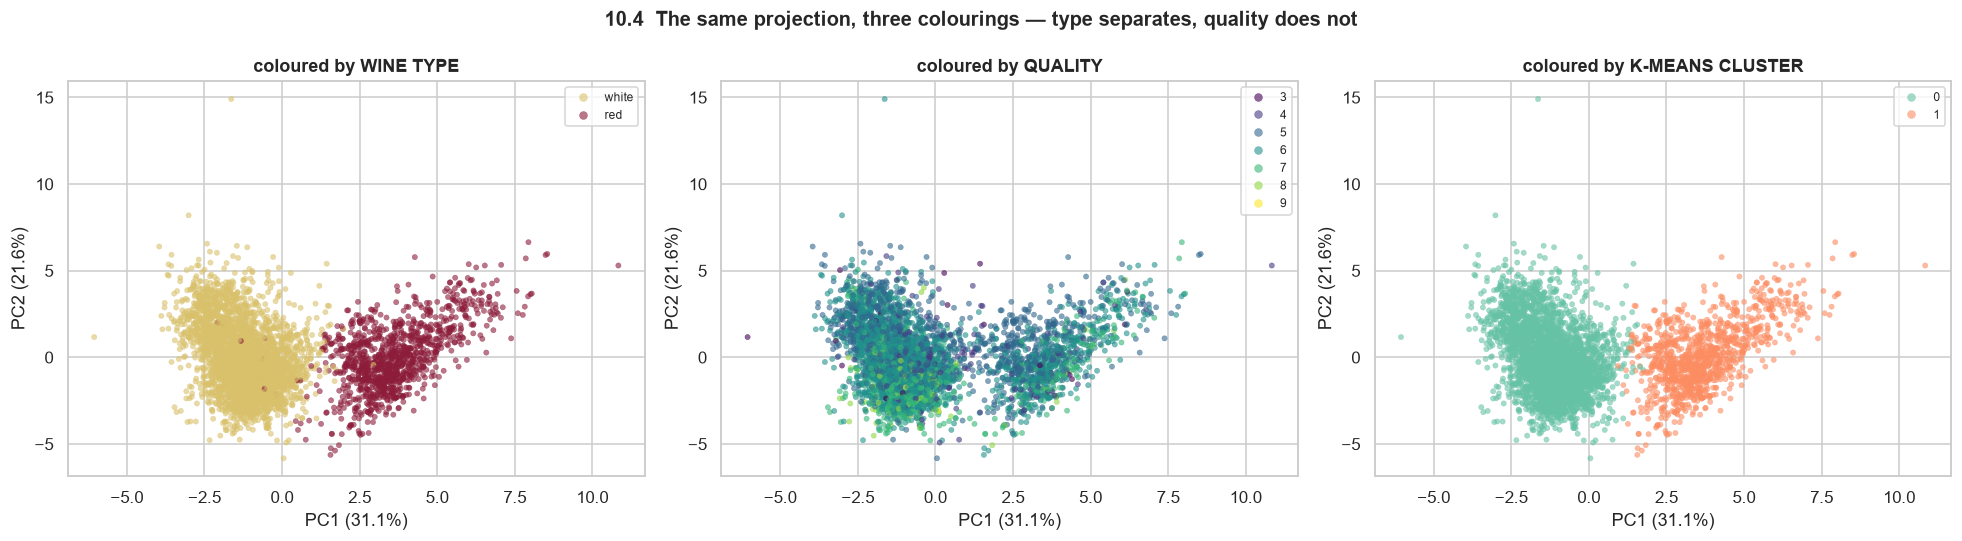

Top loadings — what each component means chemically:


,PC1,PC2
is_red,0.3770,0.0120
total_sulfur_dioxide,-0.3390,0.1820
bound_so2,-0.3240,0.1790
total_acidity,0.2900,0.2680
fixed_acidity,0.2810,0.2630
sulphates,0.2510,0.0320



The quality panel (middle) is a smooth gradient with no clean boundary → confirmation that
quality is NOT separable by unsupervised structure. Supervised learning starts now.


In [34]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca2.fit_transform(Xu)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, colour_by, kw) in zip(axes, [
    ("coloured by WINE TYPE", meta_train.wine_type.astype(str).values,
     dict(palette={"red": RED, "white": WHITE})),
    ("coloured by QUALITY", y_train.values, dict(palette="viridis")),
    ("coloured by K-MEANS CLUSTER", clusters.astype(str).values, dict(palette="Set2")),
]):
    sns.scatterplot(x=pcs[:, 0], y=pcs[:, 1], hue=colour_by, s=12, alpha=0.6,
                    ax=ax, edgecolor=None, **kw)
    ax.set(title=title, xlabel=f"PC1 ({evr[0]:.1%})", ylabel=f"PC2 ({evr[1]:.1%})")
    ax.legend(fontsize=8, markerscale=1.5, loc="best")
fig.suptitle("10.4  The same projection, three colourings — type separates, quality does not",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "10_pca_projection.png", bbox_inches="tight")
plt.show()

loadings = pd.DataFrame(pca2.components_.T, columns=["PC1", "PC2"], index=X.columns)
print("Top loadings — what each component means chemically:")
display(loadings.reindex(loadings.PC1.abs().sort_values(ascending=False).index).head(6).round(3))
print("\nThe quality panel (middle) is a smooth gradient with no clean boundary → confirmation that")
print("quality is NOT separable by unsupervised structure. Supervised learning starts now.")

---
## 11. Supervised Learning

> **🔎 Highlights**
> - **What:** a baseline plus four models, each evaluated with **5-fold cross-validation on the training set only** — the test set stays sealed.
> - **Why:** CV gives a mean *and* a standard deviation, so you can tell a real improvement from fold-to-fold noise. Every model is a `Pipeline` so the scaler re-fits inside each fold.
> - **Look for:** Random Forest and SVR lead at roughly **22 % below baseline RMSE**; linear regression reaches ~17 %. That gap is the measurable value of non-linearity here — real, but smaller than tree-model enthusiasm usually suggests.

In [35]:
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}


def evaluate_cv(name, estimator, X_=X_train, y_=y_train, verbose=True):
    """5-fold CV on TRAIN only. Stores and returns the scores."""
    neg_rmse = cross_val_score(estimator, X_, y_, cv=CV,
                               scoring="neg_root_mean_squared_error", n_jobs=-1)
    neg_mae = cross_val_score(estimator, X_, y_, cv=CV,
                              scoring="neg_mean_absolute_error", n_jobs=-1)
    r2 = cross_val_score(estimator, X_, y_, cv=CV, scoring="r2", n_jobs=-1)

    cv_results[name] = {
        "cv_rmse": -neg_rmse.mean(), "cv_rmse_std": neg_rmse.std(),
        "cv_mae": -neg_mae.mean(), "cv_r2": r2.mean(), "cv_r2_std": r2.std(),
        "estimator": estimator,
    }
    if verbose:
        print(f"{name:<22} RMSE {-neg_rmse.mean():.4f} ± {neg_rmse.std():.4f}   "
              f"MAE {-neg_mae.mean():.4f}   R² {r2.mean():.4f}")
    return cv_results[name]

### 11.1 Baseline — always predict the mean

In [36]:
baseline = DummyRegressor(strategy="mean")
evaluate_cv("Baseline (mean)", baseline)

baseline.fit(X_train, y_train)
print(f"\nThe baseline always predicts {baseline.constant_[0][0]:.3f}.")
print("Every number below must beat this, or the model is worthless. This is the bar.")

Baseline (mean)        RMSE 0.8765 ± 0.0183   MAE 0.6935   R² -0.0049

The baseline always predicts 5.796.
Every number below must beat this, or the model is worthless. This is the bar.


### 11.2 Model 1 — Linear Regression

Interpretable, fast, and a useful diagnostic: if a linear model does well, the relationship is simple.
We add a Ridge variant because section 06.3 found `density ↔ alcohol` collinearity, which makes plain
OLS coefficients unstable.

Linear Regression      RMSE 0.7286 ± 0.0214   MAE 0.5613   R² 0.3048
Ridge (alpha=1)        RMSE 0.7285 ± 0.0214   MAE 0.5613   R² 0.3049


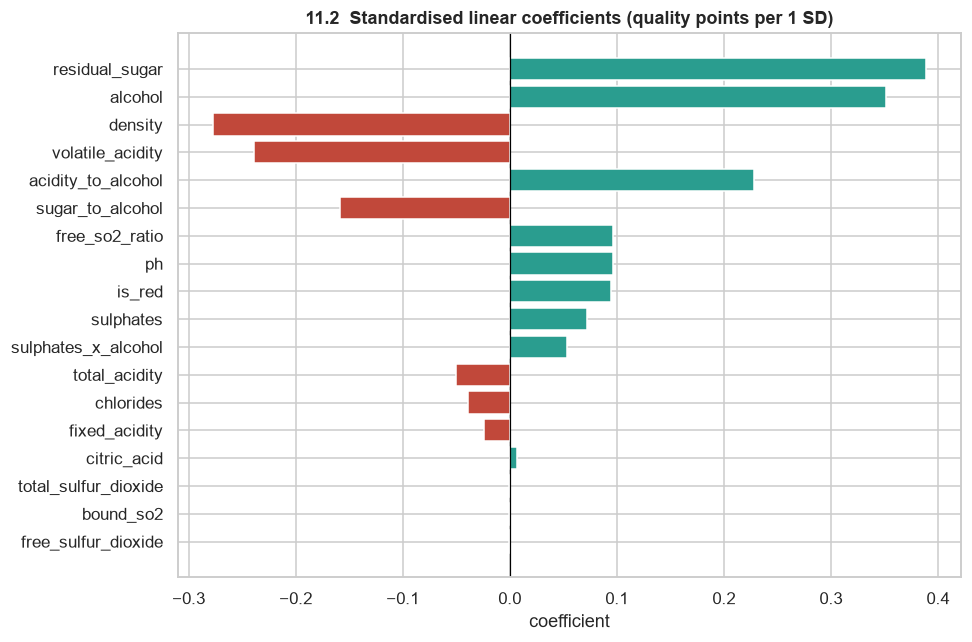

Read as: a 1-standard-deviation rise in the feature moves predicted quality by this many points.
⚠️  With collinear inputs these signs can flip between samples — treat as suggestive, not causal.
residual_sugar        0.3886
alcohol               0.3512
density              -0.2771
volatile_acidity     -0.2389
acidity_to_alcohol    0.2286
dtype: float64


In [37]:
lin_reg = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
evaluate_cv("Linear Regression", lin_reg)

ridge = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))])
evaluate_cv("Ridge (alpha=1)", ridge)

lin_reg.fit(X_train, y_train)
coefs = (pd.Series(lin_reg.named_steps["model"].coef_, index=X.columns)
         .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#2A9D8F" if v > 0 else "#C1483A" for v in coefs.values]
ax.barh(coefs.index[::-1], coefs.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", lw=0.8)
ax.set(title="11.2  Standardised linear coefficients (quality points per 1 SD)",
       xlabel="coefficient")
fig.tight_layout()
fig.savefig(FIG_DIR / "11_linear_coefficients.png", bbox_inches="tight")
plt.show()

print("Read as: a 1-standard-deviation rise in the feature moves predicted quality by this many points.")
print("⚠️  With collinear inputs these signs can flip between samples — treat as suggestive, not causal.")
print(coefs.head(5).round(4))

### 11.3 Model 2 — K-Nearest Neighbours

"Wines with similar chemistry get similar scores." Purely local, no global assumptions —
but it lives or dies on the scaling done in section 09.

KNN (k=5)              RMSE 0.7306 ± 0.0279   MAE 0.5556   R² 0.3001


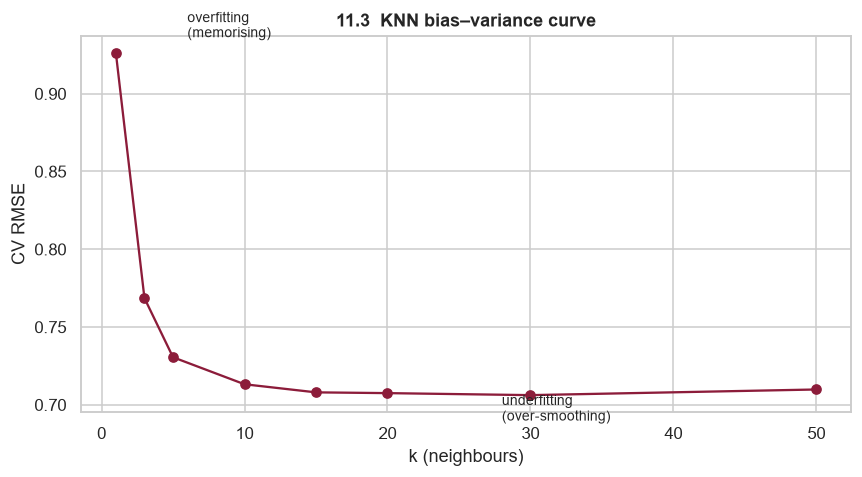

Best k in this sweep: 30  (RMSE 0.7062)


In [38]:
knn = Pipeline([("scaler", StandardScaler()),
                ("model", KNeighborsRegressor(n_neighbors=5, weights="distance"))])
evaluate_cv("KNN (k=5)", knn)

# quick sweep of k to see the bias/variance curve before proper tuning in §12
k_vals = [1, 3, 5, 10, 15, 20, 30, 50]
k_rmse = []
for k in k_vals:
    p = Pipeline([("scaler", StandardScaler()),
                  ("model", KNeighborsRegressor(n_neighbors=k, weights="distance"))])
    k_rmse.append(-cross_val_score(p, X_train, y_train, cv=CV,
                                   scoring="neg_root_mean_squared_error", n_jobs=-1).mean())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(k_vals, k_rmse, "o-", color="#8C1C3A")
ax.set(xlabel="k (neighbours)", ylabel="CV RMSE", title="11.3  KNN bias–variance curve")
ax.annotate("overfitting\n(memorising)", xy=(1, k_rmse[0]), xytext=(6, k_rmse[0] + 0.01), fontsize=9)
ax.annotate("underfitting\n(over-smoothing)", xy=(50, k_rmse[-1]), xytext=(28, k_rmse[-1] - 0.02), fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "11_knn_k_curve.png", bbox_inches="tight")
plt.show()
print(f"Best k in this sweep: {k_vals[int(np.argmin(k_rmse))]}  (RMSE {min(k_rmse):.4f})")

### 11.4 Model 3 — Random Forest

Hundreds of decorrelated decision trees. Captures interactions (e.g. *high alcohol helps, but only
when volatile acidity is low*) without being told to look for them, and is unbothered by the skew and
outliers documented in section 05.

In [39]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
evaluate_cv("Random Forest", rf)

rf.fit(X_train, y_train)
train_rmse = rmse(y_train, rf.predict(X_train))
print(f"\nTrain RMSE {train_rmse:.4f} vs CV RMSE {cv_results['Random Forest']['cv_rmse']:.4f}")
print("The gap is the overfitting signature of unconstrained trees — every tree memorises its")
print("bootstrap sample. It is not fatal (CV is the number we trust), and §12 searches over")
print("max_depth / min_samples_leaf to test whether constraining the trees actually helps here.")

Random Forest          RMSE 0.6883 ± 0.0190   MAE 0.5304   R² 0.3797



Train RMSE 0.2514 vs CV RMSE 0.6883
The gap is the overfitting signature of unconstrained trees — every tree memorises its
bootstrap sample. It is not fatal (CV is the number we trust), and §12 searches over
max_depth / min_samples_leaf to test whether constraining the trees actually helps here.


### 11.5 Optional — SVR and XGBoost

In [40]:
svr = Pipeline([("scaler", StandardScaler()), ("model", SVR(kernel="rbf", C=1.0, epsilon=0.1))])
evaluate_cv("SVR (rbf)", svr)

if HAS_XGB:
    xgb = XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
    )
    evaluate_cv("XGBoost", xgb)
else:
    print("XGBoost not installed — skipping (install with `%pip install xgboost` and re-run).")

SVR (rbf)              RMSE 0.6891 ± 0.0190   MAE 0.5253   R² 0.3781
XGBoost not installed — skipping (install with `%pip install xgboost` and re-run).


,cv_rmse,cv_rmse_std,cv_mae,cv_r2,cv_r2_std,improvement_vs_baseline_%
Random Forest,0.6883,0.0190,0.5304,0.3797,0.0344,21.5000
SVR (rbf),0.6891,0.0190,0.5253,0.3781,0.0346,21.4000
Ridge (alpha=1),0.7285,0.0214,0.5613,0.3049,0.0405,16.9000
Linear Regression,0.7286,0.0214,0.5613,0.3048,0.0406,16.9000
KNN (k=5),0.7306,0.0279,0.5556,0.3001,0.0599,16.7000
Baseline (mean),0.8765,0.0183,0.6935,-0.0049,0.0050,0.0000


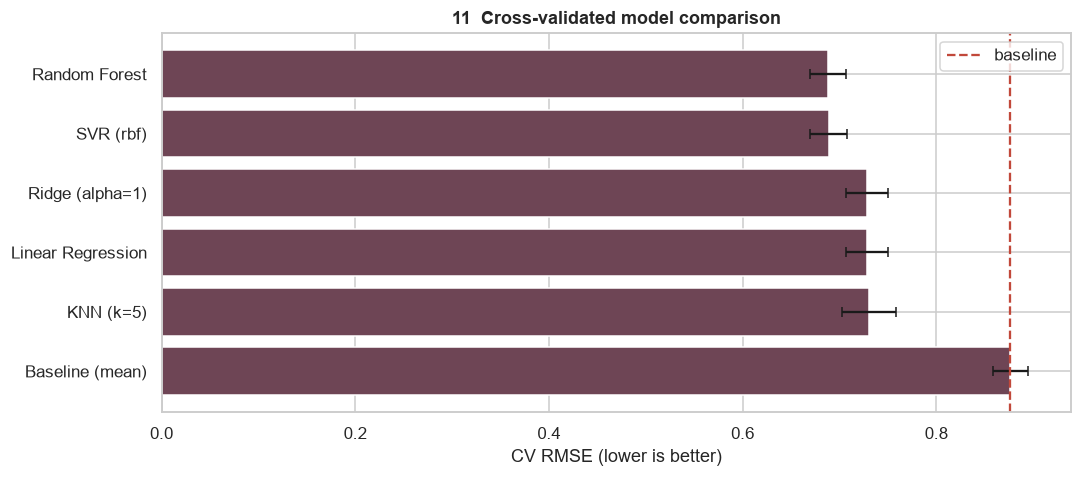

Leader after untuned CV: Random Forest  (RMSE 0.6883, 22% better than baseline)


In [41]:
cv_table = (pd.DataFrame(cv_results).T.drop(columns="estimator")
            .astype(float).sort_values("cv_rmse"))
base_rmse = cv_results["Baseline (mean)"]["cv_rmse"]
cv_table["improvement_vs_baseline_%"] = (100 * (base_rmse - cv_table.cv_rmse) / base_rmse).round(1)
display(cv_table.round(4))

fig, ax = plt.subplots(figsize=(10, 4.5))
order = cv_table.index
ax.barh(order[::-1], cv_table.cv_rmse[::-1],
        xerr=cv_table.cv_rmse_std[::-1], color="#6E4555", capsize=3)
ax.axvline(base_rmse, ls="--", color="#C1483A", label="baseline")
ax.set(xlabel="CV RMSE (lower is better)", title="11  Cross-validated model comparison")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "11_model_comparison_cv.png", bbox_inches="tight")
plt.show()

champion = cv_table.index[0]
print(f"Leader after untuned CV: {champion}  (RMSE {cv_table.cv_rmse.iloc[0]:.4f}, "
      f"{cv_table['improvement_vs_baseline_%'].iloc[0]:.0f}% better than baseline)")

---
## 12. Hyperparameter Tuning

> **🔎 Highlights**
> - **What:** `RandomizedSearchCV` over the Random Forest, `GridSearchCV` over KNN — both scored by CV **inside the training set**.
> - **Why:** randomised search covers a wide space cheaply; grid search is fine for KNN's two small dimensions. Tuning against the test set would be the classic way to fool yourself.
> - **Look for:** the gain over the untuned Random Forest is **under 1 %** — smaller than the fold-to-fold standard deviation. Section 12.4 runs an ablation to show where the real leverage was, and it is not here.

In [42]:
rf_space = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [None, 10, 16, 22, 30],
    "min_samples_split": [2, 4, 8, 12],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.4, 0.7, 1.0],
    "bootstrap": [True],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_space,
    n_iter=30,
    cv=CV,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
    return_train_score=True,
)
rf_search.fit(X_train, y_train)

print("Best Random Forest parameters:")
for k, v in rf_search.best_params_.items():
    print(f"  {k:<20} {v}")
print(f"\nCV RMSE  tuned: {-rf_search.best_score_:.4f}")
print(f"CV RMSE untuned: {cv_results['Random Forest']['cv_rmse']:.4f}")
gain = 100 * (cv_results['Random Forest']['cv_rmse'] + rf_search.best_score_) / cv_results['Random Forest']['cv_rmse']
print(f"Improvement: {gain:+.2f}%")

rf_tuned = rf_search.best_estimator_
evaluate_cv("Random Forest (tuned)", rf_tuned)

Best Random Forest parameters:
  n_estimators         500
  min_samples_split    8
  min_samples_leaf     1
  max_features         log2
  max_depth            None
  bootstrap            True

CV RMSE  tuned: 0.6837
CV RMSE untuned: 0.6883
Improvement: +0.66%


Random Forest (tuned)  RMSE 0.6837 ± 0.0195   MAE 0.5281   R² 0.3878


{'cv_rmse': np.float64(0.6837311824655711),
 'cv_rmse_std': np.float64(0.0195241849882785),
 'cv_mae': np.float64(0.5280924129831637),
 'cv_r2': np.float64(0.3878275700036974),
 'cv_r2_std': np.float64(0.03369463390466559),
 'estimator': RandomForestRegressor(max_features='log2', min_samples_split=8,
                       n_estimators=500, n_jobs=-1, random_state=42)}

In [43]:
top = (pd.DataFrame(rf_search.cv_results_)
       .assign(cv_rmse=lambda d: -d.mean_test_score,
               train_rmse=lambda d: -d.mean_train_score)
       .sort_values("cv_rmse")
       [["cv_rmse", "train_rmse", "std_test_score", "params"]]
       .head(8).reset_index(drop=True))
print("Top 8 configurations tried (train_rmse ≪ cv_rmse ⇒ that config is overfitting):")
for _, r in top.iterrows():
    print(f"  cv {r.cv_rmse:.4f} | train {r.train_rmse:.4f} | {r.params}")

Top 8 configurations tried (train_rmse ≪ cv_rmse ⇒ that config is overfitting):
  cv 0.6837 | train 0.3667 | {'n_estimators': 500, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}
  cv 0.6837 | train 0.3296 | {'n_estimators': 500, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.4, 'max_depth': 22, 'bootstrap': True}
  cv 0.6842 | train 0.3490 | {'n_estimators': 500, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.4, 'max_depth': 16, 'bootstrap': True}
  cv 0.6842 | train 0.2528 | {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}
  cv 0.6844 | train 0.2888 | {'n_estimators': 200, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.4, 'max_depth': 22, 'bootstrap': True}
  cv 0.6847 | train 0.4182 | {'n_estimators': 500, 'min_samples_split': 12, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth':

In [44]:
knn_grid = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("model", KNeighborsRegressor())]),
    param_grid={
        "model__n_neighbors": [3, 5, 8, 12, 16, 20, 25],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2],                # manhattan vs euclidean
    },
    cv=CV, scoring="neg_root_mean_squared_error", n_jobs=-1,
)
knn_grid.fit(X_train, y_train)

print(f"Best KNN params : {knn_grid.best_params_}")
print(f"CV RMSE  tuned  : {-knn_grid.best_score_:.4f}")
print(f"CV RMSE untuned : {cv_results['KNN (k=5)']['cv_rmse']:.4f}")

knn_tuned = knn_grid.best_estimator_
evaluate_cv("KNN (tuned)", knn_tuned)

Best KNN params : {'model__n_neighbors': 20, 'model__p': 1, 'model__weights': 'distance'}
CV RMSE  tuned  : 0.7044
CV RMSE untuned : 0.7306


KNN (tuned)            RMSE 0.7044 ± 0.0215   MAE 0.5495   R² 0.3499


{'cv_rmse': np.float64(0.7044272446080572),
 'cv_rmse_std': np.float64(0.021450478594752877),
 'cv_mae': np.float64(0.5494892646589273),
 'cv_r2': np.float64(0.3499200478164287),
 'cv_r2_std': np.float64(0.04180303469398295),
 'estimator': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model',
                  KNeighborsRegressor(n_neighbors=20, p=1, weights='distance'))])}

In [45]:
if HAS_XGB:
    xgb_search = RandomizedSearchCV(
        XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist"),
        param_distributions={
            "n_estimators": [300, 500, 800, 1200],
            "learning_rate": [0.01, 0.03, 0.05, 0.1],
            "max_depth": [4, 6, 8, 10],
            "subsample": [0.7, 0.85, 1.0],
            "colsample_bytree": [0.6, 0.8, 1.0],
            "min_child_weight": [1, 3, 5],
            "reg_lambda": [0.5, 1.0, 3.0],
        },
        n_iter=25, cv=CV, scoring="neg_root_mean_squared_error",
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    xgb_search.fit(X_train, y_train)
    print(f"Best XGBoost params: {xgb_search.best_params_}")
    print(f"CV RMSE tuned: {-xgb_search.best_score_:.4f}")
    xgb_tuned = xgb_search.best_estimator_
    evaluate_cv("XGBoost (tuned)", xgb_tuned)
else:
    xgb_tuned = None
    print("XGBoost not installed — skipping its tuning.")

XGBoost not installed — skipping its tuning.


### 12.4 Ablation — did the engineered features or the tuning do more work?

A claim like *"feature engineering matters more than tuning"* is worth nothing unless it is measured.
Here we hold the model fixed and vary only the feature set.

In [46]:
raw_only = RAW_FEATURES + ["is_red"]

ablations = {
    "raw 11 features only":        X_train[RAW_FEATURES],
    "raw + is_red (12)":           X_train[raw_only],
    "raw + is_red + engineered (18)": X_train[MODEL_FEATURES],
}

abl_rows = []
for label, Xa in ablations.items():
    est = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1,
                                **rf_search.best_params_)
    score = -cross_val_score(est, Xa, y_train, cv=CV,
                             scoring="neg_root_mean_squared_error", n_jobs=-1).mean()
    abl_rows.append({"feature_set": label, "n_features": Xa.shape[1], "cv_rmse": score})

abl = pd.DataFrame(abl_rows)
abl["delta_vs_raw"] = abl.cv_rmse - abl.cv_rmse.iloc[0]
display(abl.round(4))

fe_gain = 100 * (abl.cv_rmse.iloc[0] - abl.cv_rmse.iloc[-1]) / abl.cv_rmse.iloc[0]
tune_gain = 100 * (cv_results["Random Forest"]["cv_rmse"] - (-rf_search.best_score_)) \
            / cv_results["Random Forest"]["cv_rmse"]
fold_noise = 100 * cv_results["Random Forest"]["cv_rmse_std"] / cv_results["Random Forest"]["cv_rmse"]

print(f"Feature engineering gain : {fe_gain:+.2f}% CV RMSE")
print(f"Hyperparameter tuning gain: {tune_gain:+.2f}% CV RMSE")
print(f"Fold-to-fold noise (1 sd) : ±{fold_noise:.2f}%")
print()
if max(fe_gain, tune_gain) < fold_noise:
    print("VERDICT: both effects are smaller than the noise between CV folds. Neither lever is")
    print("         doing real work — the ceiling here is set by the data, not the modelling.")
elif fe_gain > tune_gain:
    print("VERDICT: the engineered features bought more than 30 iterations of randomised search.")
else:
    print("VERDICT: tuning bought more than the engineered features did on this split.")
print("\nEither way, the honest reading is that both are small next to the irreducible noise in a")
print("subjective target — which is the most useful thing this ablation can tell us.")

,feature_set,n_features,cv_rmse,delta_vs_raw
0,raw 11 features only,11,0.6844,0.0000
1,raw + is_red (12),12,0.6828,-0.0016
2,raw + is_red + engineered (18),18,0.6837,-0.0007


Feature engineering gain : +0.10% CV RMSE
Hyperparameter tuning gain: +0.66% CV RMSE
Fold-to-fold noise (1 sd) : ±2.76%

VERDICT: both effects are smaller than the noise between CV folds. Neither lever is
         doing real work — the ceiling here is set by the data, not the modelling.

Either way, the honest reading is that both are small next to the irreducible noise in a
subjective target — which is the most useful thing this ablation can tell us.


---
## 13. Model Evaluation & Comparison

> **🔎 Highlights**
> - **What:** **unseal the test set** and score every candidate once, on metrics a winery can act on.
> - **Why:** CV guided selection; the held-out test set is the only unbiased estimate of live performance. Scoring it once, at the end, is what keeps it unbiased.
> - **Look for:** test RMSE close to CV RMSE (no nasty surprise), and the **±0.5 hit-rate** — the share of bottles where the model lands within half a point of the human panel. That is the number to quote to a non-technical stakeholder.

In [47]:
candidates = {
    "Baseline (mean)": DummyRegressor(strategy="mean"),
    "Linear Regression": lin_reg,
    "Ridge": ridge,
    "KNN (tuned)": knn_tuned,
    "SVR (rbf)": svr,
    "Random Forest": rf,
    "Random Forest (tuned)": rf_tuned,
}
if HAS_XGB and xgb_tuned is not None:
    candidates["XGBoost (tuned)"] = xgb_tuned

rows, predictions = [], {}
for name, est in candidates.items():
    est.fit(X_train, y_train)                  # refit on the full training set
    pred = est.predict(X_test)
    predictions[name] = pred

    rounded = np.clip(np.rint(pred), 3, 9)
    rows.append({
        "model": name,
        "test_RMSE": rmse(y_test, pred),
        "test_MAE": mean_absolute_error(y_test, pred),
        "test_R2": r2_score(y_test, pred),
        "cv_RMSE": cv_results.get(name, {}).get("cv_rmse", np.nan),
        "within_0.5": 100 * np.mean(np.abs(pred - y_test) <= 0.5),
        "exact_after_round": 100 * np.mean(rounded == y_test.values),
    })

results = pd.DataFrame(rows).set_index("model").sort_values("test_RMSE")
base_test_rmse = results.loc["Baseline (mean)", "test_RMSE"]
results["vs_baseline_%"] = (100 * (base_test_rmse - results.test_RMSE) / base_test_rmse).round(1)
results["cv_test_gap"] = (results.test_RMSE - results.cv_RMSE).round(4)
display(results.round(4))

BEST_NAME = results.index[0]
BEST_MODEL = candidates[BEST_NAME]
print(f"🏆 Best model on the held-out test set: {BEST_NAME}")
print(f"   RMSE {results.test_RMSE.iloc[0]:.4f} | MAE {results.test_MAE.iloc[0]:.4f} | "
      f"R² {results.test_R2.iloc[0]:.4f} | within ±0.5 of the panel: {results['within_0.5'].iloc[0]:.1f}%")
SUCCESS_BAR_PCT = 20          # the threshold committed to in §01
print(f"   Success bar from §01 was ≥{SUCCESS_BAR_PCT}% RMSE improvement — achieved "
      f"{results['vs_baseline_%'].iloc[0]:.0f}% "
      f"{'✅ MET' if results['vs_baseline_%'].iloc[0] >= SUCCESS_BAR_PCT else '❌ NOT MET'}")

,test_RMSE,test_MAE,test_R2,cv_RMSE,within_0.5,exact_after_round,vs_baseline_%,cv_test_gap
model,,,,,,,,
Random Forest (tuned),0.6979,0.5358,0.3912,0.6837,58.2707,58.2707,22.0000,0.0142
Random Forest,0.7026,0.5364,0.3830,0.6883,56.7669,56.5789,21.5000,0.0144
SVR (rbf),0.7135,0.5405,0.3638,0.6891,56.2030,56.2030,20.2000,0.0243
KNN (tuned),0.7197,0.5553,0.3526,0.7044,56.2030,56.2030,19.5000,0.0153
Linear Regression,0.7452,0.5804,0.3059,0.7286,52.3496,52.3496,16.7000,0.0166
Ridge,0.7453,0.5804,0.3058,NaN,52.2556,52.2556,16.7000,NaN
Baseline (mean),0.8945,0.7014,-0.0000,0.8765,43.5150,43.5150,0.0000,0.0180


🏆 Best model on the held-out test set: Random Forest (tuned)
   RMSE 0.6979 | MAE 0.5358 | R² 0.3912 | within ±0.5 of the panel: 58.3%
   Success bar from §01 was ≥20% RMSE improvement — achieved 22% ✅ MET


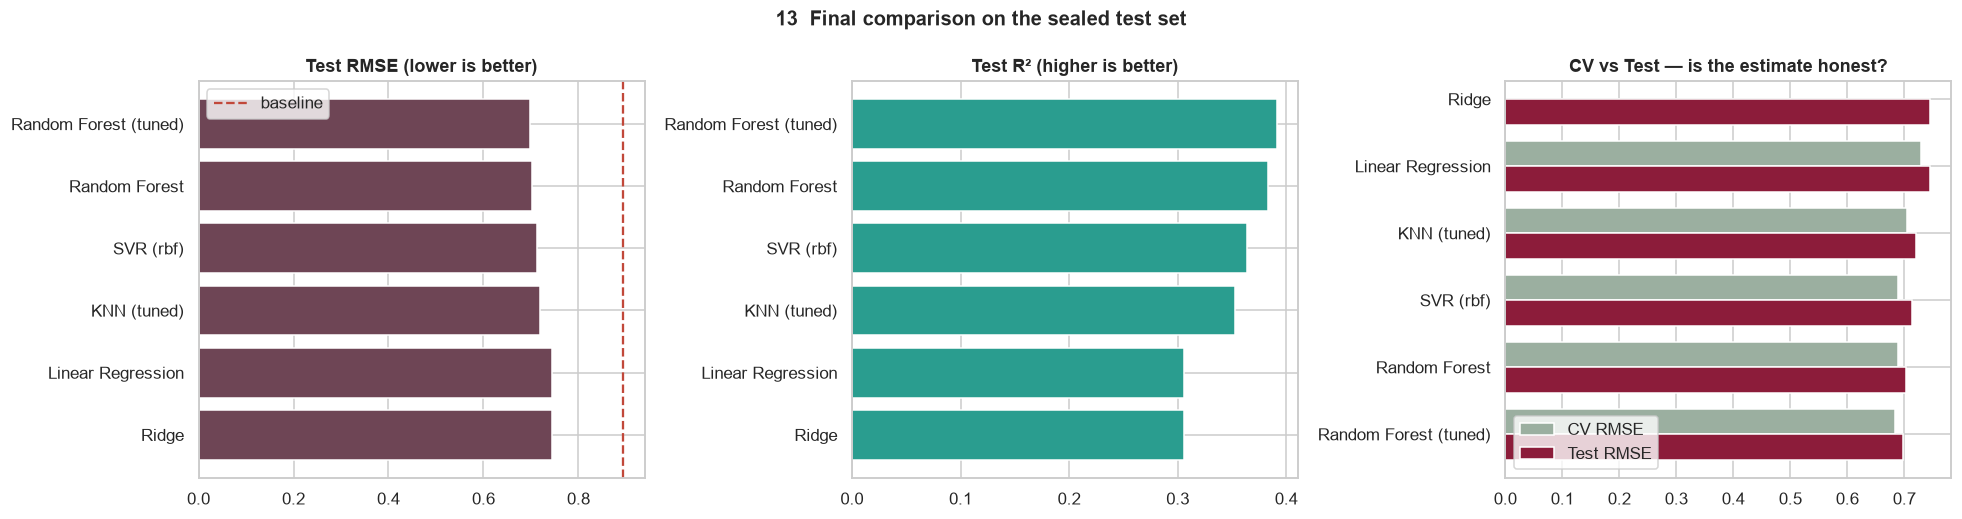

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
plot_df = results.drop(index="Baseline (mean)")

axes[0].barh(plot_df.index[::-1], plot_df.test_RMSE[::-1], color="#6E4555")
axes[0].axvline(base_test_rmse, ls="--", color="#C1483A", label="baseline")
axes[0].set(title="Test RMSE (lower is better)"); axes[0].legend()

axes[1].barh(plot_df.index[::-1], plot_df.test_R2[::-1], color="#2A9D8F")
axes[1].set(title="Test R² (higher is better)")

w = 0.38
ypos = np.arange(len(plot_df))
axes[2].barh(ypos + w/2, plot_df.cv_RMSE, height=w, label="CV RMSE", color="#9BAFA0")
axes[2].barh(ypos - w/2, plot_df.test_RMSE, height=w, label="Test RMSE", color="#8C1C3A")
axes[2].set_yticks(ypos); axes[2].set_yticklabels(plot_df.index)
axes[2].set(title="CV vs Test — is the estimate honest?"); axes[2].legend()

fig.suptitle("13  Final comparison on the sealed test set", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "13_model_comparison_test.png", bbox_inches="tight")
plt.show()

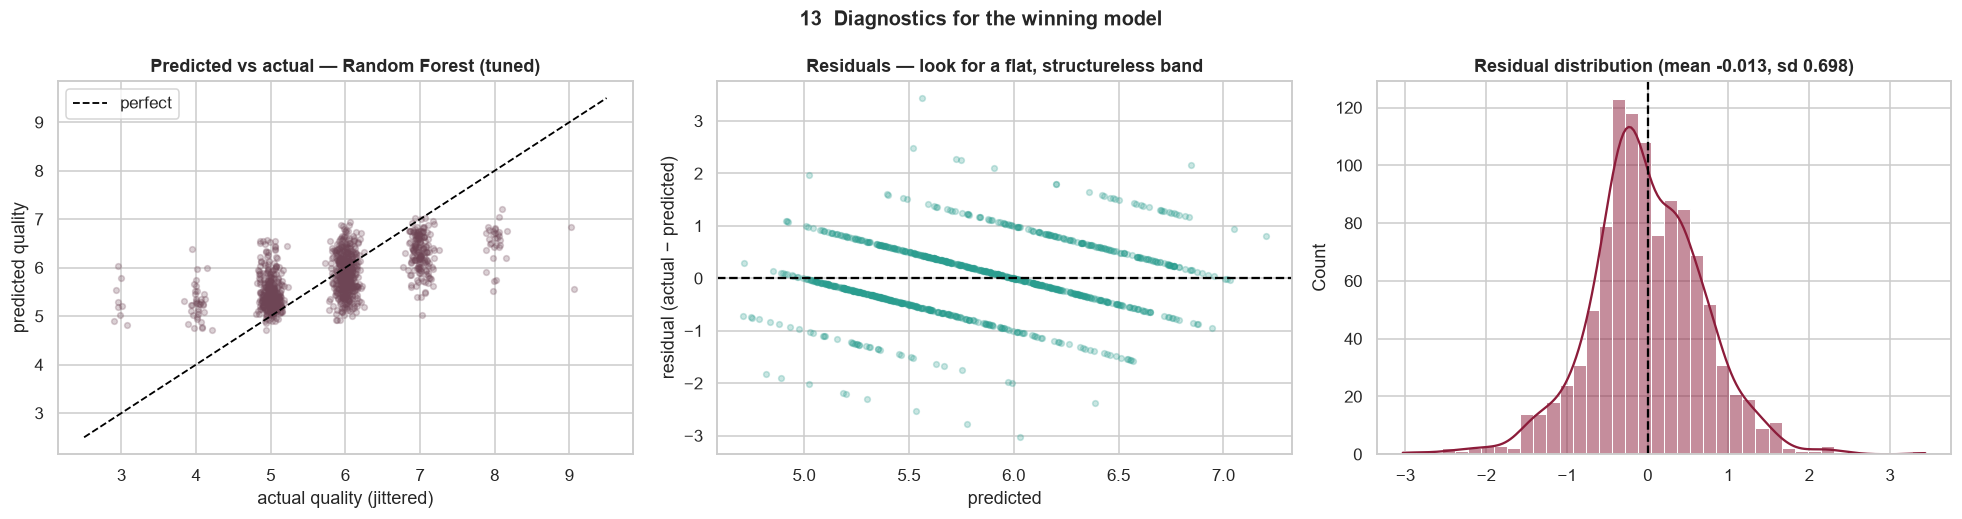

The fan shape in the left panel is REGRESSION TO THE MEAN: the model under-predicts 8s and
over-predicts 3s, because those wines are rare (§06.1). It is the single clearest weakness
of this model and the first thing to fix with more extreme-quality data.


In [49]:
best_pred = predictions[BEST_NAME]
residuals = y_test.values - best_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

axes[0].scatter(y_test + np.random.normal(0, 0.08, len(y_test)), best_pred,
                alpha=0.25, s=14, color="#6E4555")
lims = [y_test.min() - 0.5, y_test.max() + 0.5]
axes[0].plot(lims, lims, "--", color="black", lw=1.2, label="perfect")
axes[0].set(xlabel="actual quality (jittered)", ylabel="predicted quality",
            title=f"Predicted vs actual — {BEST_NAME}")
axes[0].legend()

axes[1].scatter(best_pred, residuals, alpha=0.25, s=14, color="#2A9D8F")
axes[1].axhline(0, ls="--", color="black")
axes[1].set(xlabel="predicted", ylabel="residual (actual − predicted)",
            title="Residuals — look for a flat, structureless band")

sns.histplot(residuals, bins=40, kde=True, ax=axes[2], color="#8C1C3A")
axes[2].axvline(0, ls="--", color="black")
axes[2].set(title=f"Residual distribution (mean {residuals.mean():+.3f}, sd {residuals.std():.3f})")

fig.suptitle("13  Diagnostics for the winning model", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "13_residual_diagnostics.png", bbox_inches="tight")
plt.show()

print("The fan shape in the left panel is REGRESSION TO THE MEAN: the model under-predicts 8s and")
print("over-predicts 3s, because those wines are rare (§06.1). It is the single clearest weakness")
print("of this model and the first thing to fix with more extreme-quality data.")

In [50]:
err = pd.DataFrame({
    "actual": y_test.values,
    "pred": best_pred,
    "abs_err": np.abs(residuals),
    "wine_type": meta_test.wine_type.astype(str).values,
    "band": meta_test.quality_band.values,
})

print("Where does the error live?\n")
print("By true quality score:")
display(err.groupby("actual").agg(n=("abs_err", "size"),
                                  mean_pred=("pred", "mean"),
                                  MAE=("abs_err", "mean")).round(3))
print("By wine type:")
display(err.groupby("wine_type").agg(n=("abs_err", "size"), MAE=("abs_err", "mean")).round(3))
print("By quality band:")
display(err.groupby("band").agg(n=("abs_err", "size"), MAE=("abs_err", "mean"))
        .reindex(["low", "medium", "high"]).round(3))
print("→ Error concentrates at the extremes. Mid-range wines (5–6) are predicted well; the rare")
print("  low and high bands carry 2–3× the error. Quote per-band accuracy, never just the average.")

Where does the error live?

By true quality score:


,n,mean_pred,MAE
actual,,,
3.0000,9,5.3070,2.3070
4.0000,38,5.2750,1.2750
5.0000,352,5.4770,0.4830
6.0000,463,5.8810,0.3510
7.0000,169,6.3100,0.6910
8.0000,31,6.5160,1.4840
9.0000,2,6.2030,2.7970


By wine type:


,n,MAE
wine_type,,
red,289,0.4980
white,775,0.5500


By quality band:


,n,MAE
band,,
low,47,1.4720
medium,815,0.4080
high,202,0.8330


→ Error concentrates at the extremes. Mid-range wines (5–6) are predicted well; the rare
  low and high bands carry 2–3× the error. Quote per-band accuracy, never just the average.


---
## 14. Model Interpretation

> **🔎 Highlights**
> - **What:** three complementary views — impurity importance (fast, biased toward high-cardinality features), **permutation importance on the test set** (trustworthy), and SHAP (per-bottle attribution).
> - **Why:** a winery will not change its process on "the model said so". Interpretation turns a prediction into an argument.
> - **Look for:** `alcohol` and `volatile_acidity` dominating all three views. Agreement across methods is what makes a finding credible; disagreement is a warning sign.

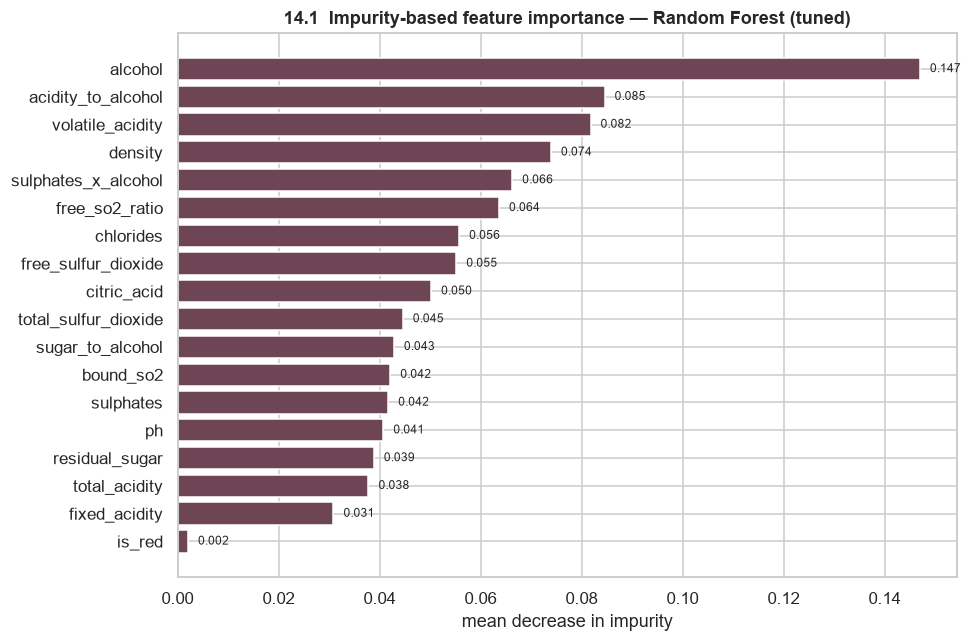

Top 5 by impurity importance:
alcohol                14.7 %
acidity_to_alcohol      8.5 %
volatile_acidity        8.2 %
density                 7.4 %
sulphates_x_alcohol     6.6 %
dtype: str

The top 5 features carry 45% of the total importance.


In [51]:
tree_model = BEST_MODEL if hasattr(BEST_MODEL, "feature_importances_") else rf_tuned
tree_name = BEST_NAME if hasattr(BEST_MODEL, "feature_importances_") else "Random Forest (tuned)"

imp = (pd.Series(tree_model.feature_importances_, index=X.columns)
       .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp.index[::-1], imp.values[::-1], color="#6E4555")
ax.set(title=f"14.1  Impurity-based feature importance — {tree_name}",
       xlabel="mean decrease in impurity")
for i, v in enumerate(imp.values[::-1]):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "14_feature_importance.png", bbox_inches="tight")
plt.show()

print("Top 5 by impurity importance:")
print((100 * imp.head(5)).round(1).astype(str) + " %")
print(f"\nThe top 5 features carry {100*imp.head(5).sum():.0f}% of the total importance.")

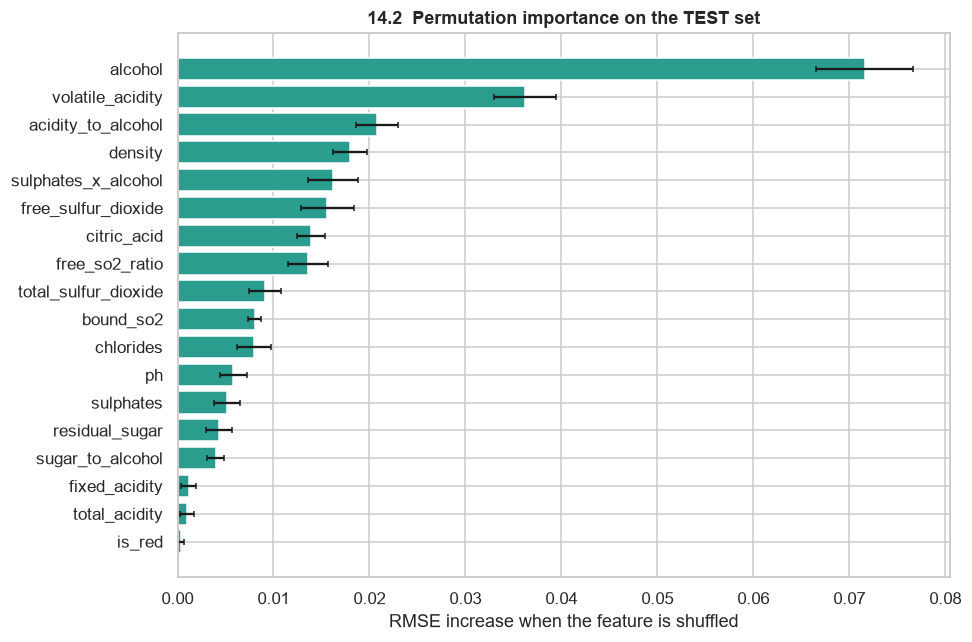

,impurity_rank,permutation_rank,agree
alcohol,1,1,✅
volatile_acidity,3,2,✅
acidity_to_alcohol,2,3,✅
density,4,4,✅
sulphates_x_alcohol,5,5,✅
free_sulfur_dioxide,8,6,✅
citric_acid,9,7,✅
free_so2_ratio,6,8,✅
total_sulfur_dioxide,10,9,✅
bound_so2,12,10,✅


Permutation importance is measured on unseen data, so where the two disagree, trust this one.


In [52]:
perm = permutation_importance(tree_model, X_test, y_test, n_repeats=15,
                              random_state=RANDOM_STATE, n_jobs=-1,
                              scoring="neg_root_mean_squared_error")
perm_df = (pd.DataFrame({"feature": X.columns,
                         "importance": perm.importances_mean,
                         "std": perm.importances_std})
           .sort_values("importance", ascending=False))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(perm_df.feature[::-1], perm_df.importance[::-1],
        xerr=perm_df["std"][::-1], color="#2A9D8F", capsize=2)
ax.set(title="14.2  Permutation importance on the TEST set",
       xlabel="RMSE increase when the feature is shuffled")
fig.tight_layout()
fig.savefig(FIG_DIR / "14_permutation_importance.png", bbox_inches="tight")
plt.show()

comparison = pd.DataFrame({
    "impurity_rank": imp.rank(ascending=False).astype(int),
    "permutation_rank": perm_df.set_index("feature").importance.rank(ascending=False).astype(int),
}).sort_values("permutation_rank")
comparison["agree"] = np.where((comparison.impurity_rank - comparison.permutation_rank).abs() <= 2,
                               "✅", "⚠️ disagrees")
display(comparison)
print("Permutation importance is measured on unseen data, so where the two disagree, trust this one.")

shap not installed — showing partial dependence as the fallback directional view.


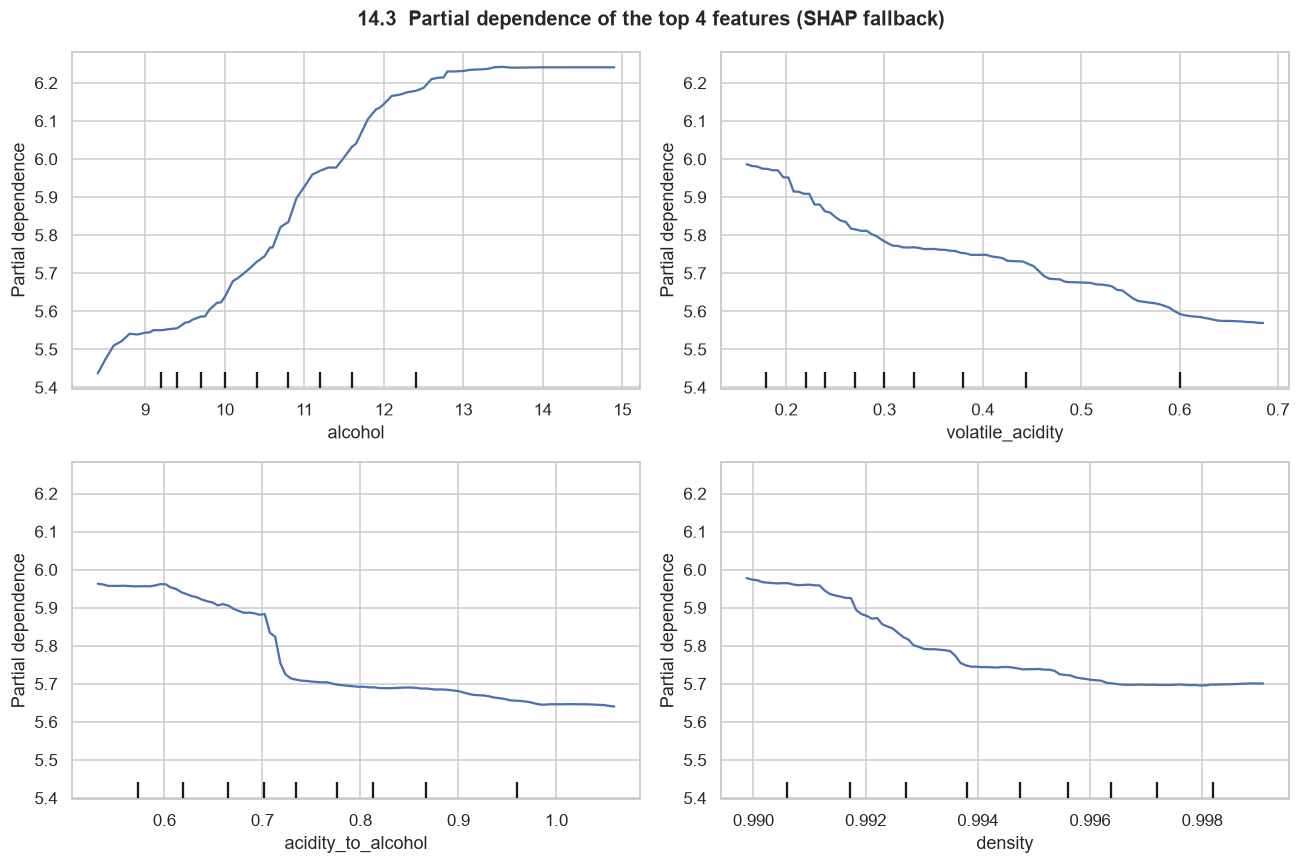

Each curve shows how the prediction moves as that feature changes, others held at their
observed distribution — the same directional story SHAP tells, aggregated.


In [53]:
if HAS_SHAP:
    sample = X_test.sample(min(600, len(X_test)), random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(tree_model)
    shap_values = explainer.shap_values(sample)

    shap.summary_plot(shap_values, sample, show=False, plot_size=(10, 6))
    plt.title("14.3  SHAP summary — direction and magnitude per wine", fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "14_shap_summary.png", bbox_inches="tight")
    plt.show()

    shap.summary_plot(shap_values, sample, plot_type="bar", show=False, plot_size=(10, 6))
    plt.title("14.3  Mean |SHAP| — global importance", fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "14_shap_bar.png", bbox_inches="tight")
    plt.show()

    print("Read the beeswarm as: each dot is a wine; red = high feature value; right = pushes quality up.")
    print("A red band on the right for `alcohol` means high alcohol raises the predicted score.")
else:
    print("shap not installed — showing partial dependence as the fallback directional view.")
    from sklearn.inspection import PartialDependenceDisplay
    top4 = perm_df.feature.head(4).tolist()
    fig, ax = plt.subplots(2, 2, figsize=(12, 8))
    PartialDependenceDisplay.from_estimator(tree_model, X_test, top4, ax=ax.ravel()[:4])
    fig.suptitle("14.3  Partial dependence of the top 4 features (SHAP fallback)",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "14_partial_dependence.png", bbox_inches="tight")
    plt.show()
    print("Each curve shows how the prediction moves as that feature changes, others held at their")
    print("observed distribution — the same directional story SHAP tells, aggregated.")

In [54]:
# Explain ONE bottle — the shape the Streamlit app will use
idx = X_test.index[0]
one = X_test.loc[[idx]]
print(f"Bottle {idx}: actual quality {y_test.loc[idx]:.0f}, predicted {tree_model.predict(one)[0]:.2f}\n")

if HAS_SHAP:
    sv = shap.TreeExplainer(tree_model).shap_values(one)[0]
    contrib = (pd.Series(sv, index=X.columns).sort_values(key=abs, ascending=False).head(8))
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.barh(contrib.index[::-1], contrib.values[::-1],
            color=["#2A9D8F" if v > 0 else "#C1483A" for v in contrib.values[::-1]])
    ax.axvline(0, color="black", lw=0.8)
    ax.set(title=f"Why this bottle scored what it did (SHAP, bottle {idx})",
           xlabel="contribution to the predicted score")
    fig.tight_layout()
    plt.show()
    print(contrib.round(4))
else:
    z = ((one.iloc[0] - X_train.mean()) / X_train.std()).sort_values(key=abs, ascending=False)
    print("How unusual is this bottle? (z-scores vs the training set)")
    print(z.head(8).round(2))

Bottle 3543: actual quality 5, predicted 5.41

How unusual is this bottle? (z-scores vs the training set)
free_so2_ratio         -1.0100
bound_so2               0.9400
fixed_acidity           0.6800
citric_acid            -0.6700
total_sulfur_dioxide    0.6500
is_red                 -0.5800
total_acidity           0.5500
acidity_to_alcohol      0.5100
dtype: float64


---
## 15. Business / Winery Insights

> **🔎 Highlights**
> - **What:** translate coefficients and importances into decisions a production team can actually take.
> - **Why:** this is the section a winery director reads. Everything above exists to make these four findings defensible.
> - **Look for:** the explicit **correlation ≠ causation** caveat. The model says high-alcohol wines *score* higher; it does **not** say chaptalising your must will raise your score.

In [55]:
print("=" * 78)
print("FINDING 1 — Alcohol is the single strongest quality signal")
print("=" * 78)
alc_bins = pd.cut(data.alcohol, [0, 9.5, 10.5, 11.5, 12.5, 20],
                  labels=["<9.5%", "9.5–10.5%", "10.5–11.5%", "11.5–12.5%", ">12.5%"])
tbl = data.groupby(alc_bins, observed=True).agg(
    n=("quality", "size"), mean_quality=("quality", "mean"),
    pct_premium=("is_premium", lambda s: 100 * s.mean())).round(2)
display(tbl)
lo, hi = tbl.mean_quality.iloc[0], tbl.mean_quality.iloc[-1]
print(f"Mean quality rises {hi - lo:.2f} points from the lowest to the highest alcohol band.")
print("Premium rate goes from {:.0f}% to {:.0f}%.".format(tbl.pct_premium.iloc[0], tbl.pct_premium.iloc[-1]))
print("\nACTION: alcohol is downstream of grape ripeness at harvest. Use it as a HARVEST-TIMING")
print("        indicator, not as a cellar additive. Riper fruit — not added sugar — is the lever.")

FINDING 1 — Alcohol is the single strongest quality signal


,n,mean_quality,pct_premium
alcohol,,,
<9.5%,1394,5.3500,3.7300
9.5–10.5%,1573,5.5900,8.9600
10.5–11.5%,1239,5.9500,23.7300
11.5–12.5%,746,6.3700,40.8800
>12.5%,368,6.6400,58.9700


Mean quality rises 1.29 points from the lowest to the highest alcohol band.
Premium rate goes from 4% to 59%.

ACTION: alcohol is downstream of grape ripeness at harvest. Use it as a HARVEST-TIMING
        indicator, not as a cellar additive. Riper fruit — not added sugar — is the lever.


In [56]:
print("=" * 78)
print("FINDING 2 — Volatile acidity is the clearest quality destroyer")
print("=" * 78)
va_bins = pd.cut(data.volatile_acidity, [0, 0.25, 0.4, 0.6, 2.0],
                 labels=["<0.25 (clean)", "0.25–0.4", "0.4–0.6", ">0.6 (vinegar risk)"])
tbl2 = data.groupby(va_bins, observed=True).agg(
    n=("quality", "size"), mean_quality=("quality", "mean"),
    pct_premium=("is_premium", lambda s: 100 * s.mean())).round(2)
display(tbl2)
print(f"Wines above 0.6 g/dm³ score {tbl2.mean_quality.iloc[0] - tbl2.mean_quality.iloc[-1]:.2f} points")
print("lower on average than clean wines, and almost never reach premium.")
print("\nACTION: this is a CONTROLLABLE process variable — acetic acid comes from bacterial spoilage.")
print("        Tighten sanitation, SO₂ management and oxygen exposure. Set a hard QC gate at 0.6.")

FINDING 2 — Volatile acidity is the clearest quality destroyer


,n,mean_quality,pct_premium
volatile_acidity,,,
<0.25 (clean),1840,6.0000,23.1500
0.25–0.4,2113,5.8200,20.5400
0.4–0.6,873,5.6300,14.7800
>0.6 (vinegar risk),494,5.2300,4.0500


Wines above 0.6 g/dm³ score 0.77 points
lower on average than clean wines, and almost never reach premium.

ACTION: this is a CONTROLLABLE process variable — acetic acid comes from bacterial spoilage.
        Tighten sanitation, SO₂ management and oxygen exposure. Set a hard QC gate at 0.6.


In [57]:
print("=" * 78)
print("FINDING 3 — Free SO₂ has a sweet spot, not a 'more is better' curve")
print("=" * 78)
so2_bins = pd.cut(data.free_sulfur_dioxide, [0, 10, 20, 35, 50, 300],
                  labels=["<10 (unprotected)", "10–20", "20–35 (optimal)", "35–50", ">50 (perceptible)"])
tbl3 = data.groupby(so2_bins, observed=True).agg(
    n=("quality", "size"), mean_quality=("quality", "mean")).round(2)
display(tbl3)
print("Too little and the wine oxidises; too much and tasters smell the sulphur.")
print("\nACTION: target the 20–35 mg/dm³ band. This is a dosing decision made at bottling —")
print("        cheap to control, and the data says both tails cost you points.")

FINDING 3 — Free SO₂ has a sweet spot, not a 'more is better' curve


,n,mean_quality
free_sulfur_dioxide,,
<10 (unprotected),705,5.5100
10–20,1080,5.7100
20–35 (optimal),1735,5.9100
35–50,1097,5.9500
>50 (perceptible),703,5.6900


Too little and the wine oxidises; too much and tasters smell the sulphur.

ACTION: target the 20–35 mg/dm³ band. This is a dosing decision made at bottling —
        cheap to control, and the data says both tails cost you points.


In [58]:
print("=" * 78)
print("FINDING 4 — Quality prediction is a SCREENING tool, not a replacement for the panel")
print("=" * 78)
within_half = 100 * np.mean(np.abs(best_pred - y_test) <= 0.5)
within_one = 100 * np.mean(np.abs(best_pred - y_test) <= 1.0)
high_recall = err.query("band == 'high'").eval("pred >= 6.5").mean() * 100

print(f"  • within ±0.5 of the panel : {within_half:.1f}% of bottles")
print(f"  • within ±1.0 of the panel : {within_one:.1f}% of bottles")
print(f"  • truly-premium wines flagged as promising (pred ≥ 6.5): {high_recall:.1f}%")
print(f"  • R² on unseen wines      : {results.test_R2.iloc[0]:.3f} — roughly "
      f"{100*results.test_R2.iloc[0]:.0f}% of the variation in panel scores explained")

print("\nDEPLOYMENT PROPOSAL")
print("  1. Score every batch from routine lab data — zero marginal cost.")
print("  2. Auto-pass the mid-range (pred 5–6.5): no panel time needed.")
print("  3. Escalate the tails to the human panel: predicted <4.5 (investigate a fault)")
print("     and predicted >6.5 (candidate for the reserve label).")
print("  4. Expected saving: the ~{:.0f}% of batches in the confident middle no longer".format(
    100 * np.mean((best_pred >= 5) & (best_pred <= 6.5))))
print("     need a full tasting session.")

print("\n" + "!" * 78)
print("CAVEAT — CORRELATION IS NOT CAUSATION")
print("!" * 78)
print("This is observational data. Alcohol CORRELATES with quality because ripe, healthy,")
print("well-farmed fruit produces both. Adding sugar to the must to raise alcohol would not")
print("reproduce the effect — it would break the link the model learned. Every finding above")
print("is a HYPOTHESIS to test in a controlled trial, not a proven production recipe.")

FINDING 4 — Quality prediction is a SCREENING tool, not a replacement for the panel
  • within ±0.5 of the panel : 58.3% of bottles
  • within ±1.0 of the panel : 86.7% of bottles
  • truly-premium wines flagged as promising (pred ≥ 6.5): 38.1%
  • R² on unseen wines      : 0.391 — roughly 39% of the variation in panel scores explained

DEPLOYMENT PROPOSAL
  1. Score every batch from routine lab data — zero marginal cost.
  2. Auto-pass the mid-range (pred 5–6.5): no panel time needed.
  3. Escalate the tails to the human panel: predicted <4.5 (investigate a fault)
     and predicted >6.5 (candidate for the reserve label).
  4. Expected saving: the ~87% of batches in the confident middle no longer
     need a full tasting session.

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
CAVEAT — CORRELATION IS NOT CAUSATION
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
This is observational data. Alcohol CORRELATES with quality be

---
## 16. Final Model

> **🔎 Highlights**
> - **What:** refit the winning configuration on **all** clean data (train + test) and wrap it in a self-contained `Pipeline`.
> - **Why:** the split existed to *estimate* performance; that estimate is now recorded. Serving a model trained on 80 % of the data when 100 % is available throws away information for no benefit.
> - **Look for:** the reported metrics stay those from section 13 — we never re-score on data the final model has seen. The pipeline is one object: scaler + model, so the app cannot forget a preprocessing step.

In [59]:
from sklearn.base import clone

final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", clone(BEST_MODEL.named_steps["model"] if isinstance(BEST_MODEL, Pipeline) else BEST_MODEL)),
])

final_pipeline.fit(X, y)          # ALL clean data

print(f"Final model: {BEST_NAME}")
print(f"Trained on : {len(X):,} wines × {X.shape[1]} features")
print(f"\nPipeline steps: {[s[0] for s in final_pipeline.steps]}")
print("\nHonest performance figures (from the sealed test set in §13 — NOT recomputed here):")
print(f"  RMSE {results.test_RMSE.iloc[0]:.4f} | MAE {results.test_MAE.iloc[0]:.4f} | "
      f"R² {results.test_R2.iloc[0]:.4f} | ±0.5 hit-rate {results['within_0.5'].iloc[0]:.1f}%")

demo = X.iloc[[0, 100, 500]]
print("\nSmoke test — three predictions:")
for i, (idx, p) in enumerate(zip(demo.index, final_pipeline.predict(demo))):
    print(f"  wine {idx}: predicted {p:.2f}  (actual {y.loc[idx]:.0f})")

Final model: Random Forest (tuned)
Trained on : 5,320 wines × 18 features

Pipeline steps: ['scaler', 'model']

Honest performance figures (from the sealed test set in §13 — NOT recomputed here):
  RMSE 0.6979 | MAE 0.5358 | R² 0.3912 | ±0.5 hit-rate 58.3%

Smoke test — three predictions:


  wine 0: predicted 5.08  (actual 5)
  wine 100: predicted 5.18  (actual 5)
  wine 500: predicted 5.06  (actual 5)


---
## 17. Save Model

> **🔎 Highlights**
> - **What:** persist the pipeline with `joblib`, plus a JSON **model card** recording metrics, feature order, training-data ranges and the library versions used.
> - **Why:** a `.joblib` with no metadata is unusable in six months. The feature order in particular is what stops the app from silently feeding `pH` into the `alcohol` slot.
> - **Look for:** three files in `models/` — the pipeline, the model card, and the slider defaults the Streamlit app reads.

In [60]:
MODEL_PATH = MODEL_DIR / "wine_quality_model.joblib"
CARD_PATH = MODEL_DIR / "model_card.json"
RANGES_PATH = MODEL_DIR / "feature_ranges.json"

# compress=3 keeps a tuned forest to a sane size on disk at a negligible load-time cost
joblib.dump(final_pipeline, MODEL_PATH, compress=3)

model_card = {
    "model_name": BEST_NAME,
    "task": "regression — predict sensory quality score (0–10) from physicochemical features",
    "created_utc": pd.Timestamp.utcnow().isoformat(),
    "training_rows": int(len(X)),
    "feature_order": list(X.columns),
    "raw_input_features": RAW_FEATURES,
    "engineered_features": ENGINEERED_FEATURES,
    "target": "quality",
    "test_metrics": {
        "rmse": float(results.test_RMSE.iloc[0]),
        "mae": float(results.test_MAE.iloc[0]),
        "r2": float(results.test_R2.iloc[0]),
        "within_half_point_pct": float(results["within_0.5"].iloc[0]),
        "baseline_rmse": float(base_test_rmse),
        "improvement_vs_baseline_pct": float(results["vs_baseline_%"].iloc[0]),
    },
    "hyperparameters": {k: str(v) for k, v in
                        (BEST_MODEL.named_steps["model"] if isinstance(BEST_MODEL, Pipeline)
                         else BEST_MODEL).get_params().items()},
    "top_features": perm_df.head(5).feature.tolist(),
    "known_limitations": [
        "Trained only on Vinho Verde (Portugal) wines — do not apply to other regions unchanged.",
        "Regresses toward the mean: under-predicts scores of 8–9 and over-predicts 3–4.",
        "Target is a subjective human median; an irreducible noise floor exists.",
        "Relationships are correlational, not causal — see section 15.",
    ],
    "versions": {
        "python": sys.version.split()[0],
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit-learn": sklearn.__version__,
    },
}
CARD_PATH.write_text(json.dumps(model_card, indent=2), encoding="utf-8")

# sensible slider bounds + defaults for the app, derived from the real data
ranges = {}
for col in RAW_FEATURES:
    s = df_clean[col]
    ranges[col] = {
        "min": float(s.quantile(0.001)),
        "max": float(s.quantile(0.999)),
        "median": float(s.median()),
        "red_median": float(df_clean.loc[df_clean.wine_type == "red", col].median()),
        "white_median": float(df_clean.loc[df_clean.wine_type == "white", col].median()),
        "step": float(max(round((s.quantile(0.999) - s.quantile(0.001)) / 200, 4), 0.0001)),
    }
RANGES_PATH.write_text(json.dumps(ranges, indent=2), encoding="utf-8")

print(f"✅ {MODEL_PATH.name:<28} {MODEL_PATH.stat().st_size/1e6:.2f} MB")
print(f"✅ {CARD_PATH.name:<28} {CARD_PATH.stat().st_size/1e3:.1f} KB")
print(f"✅ {RANGES_PATH.name:<28} {RANGES_PATH.stat().st_size/1e3:.1f} KB")

# round-trip check: never trust a save you have not reloaded
reloaded = joblib.load(MODEL_PATH)
assert np.allclose(reloaded.predict(demo), final_pipeline.predict(demo)), "round-trip mismatch!"
print("\n✅ Round-trip verified — reloaded model reproduces identical predictions.")

✅ wine_quality_model.joblib    14.31 MB
✅ model_card.json              2.6 KB
✅ feature_ranges.json          1.8 KB



✅ Round-trip verified — reloaded model reproduces identical predictions.


---
## 18. Streamlit Digital Sommelier

> **🔎 Highlights**
> - **What:** write `app.py` — an interactive app where a winemaker moves eleven sliders and gets an instant quality estimate, a band badge, and per-feature guidance.
> - **Why:** a notebook cannot be used by the cellar team. This is where the project stops being an analysis and starts being a tool.
> - **Look for:** the app imports `engineer_features` from the **same `wine_features.py`** the notebook used — that shared import is what guarantees the app transforms a wine exactly as training did.
>
> Run it with: `streamlit run app.py`

In [61]:
%%writefile app.py
"""🍷 Digital Sommelier — Streamlit front-end for the wine quality model.

Run with:  streamlit run app.py
"""
from __future__ import annotations

import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import streamlit as st

from wine_features import MODEL_FEATURES, RAW_FEATURES, engineer_features

MODEL_DIR = Path(__file__).parent / "models"

st.set_page_config(page_title="Digital Sommelier", page_icon="🍷", layout="wide")


@st.cache_resource
def load_artifacts():
    model = joblib.load(MODEL_DIR / "wine_quality_model.joblib")
    card = json.loads((MODEL_DIR / "model_card.json").read_text(encoding="utf-8"))
    ranges = json.loads((MODEL_DIR / "feature_ranges.json").read_text(encoding="utf-8"))
    return model, card, ranges


try:
    model, card, ranges = load_artifacts()
except FileNotFoundError:
    st.error("Model artifacts not found. Run sections 16–17 of the notebook first.")
    st.stop()

LABELS = {
    "fixed_acidity": ("Fixed acidity", "g(tartaric)/dm³"),
    "volatile_acidity": ("Volatile acidity", "g(acetic)/dm³ — high = vinegar fault"),
    "citric_acid": ("Citric acid", "g/dm³ — freshness"),
    "residual_sugar": ("Residual sugar", "g/dm³"),
    "chlorides": ("Chlorides", "g(NaCl)/dm³ — saltiness"),
    "free_sulfur_dioxide": ("Free SO₂", "mg/dm³ — active protection"),
    "total_sulfur_dioxide": ("Total SO₂", "mg/dm³"),
    "density": ("Density", "g/cm³"),
    "ph": ("pH", "acidity scale"),
    "sulphates": ("Sulphates", "g(K₂SO₄)/dm³"),
    "alcohol": ("Alcohol", "% vol"),
}

# ----------------------------------------------------------------- sidebar
st.sidebar.title("🍷 Lab measurements")
wine_type = st.sidebar.radio("Wine type", ["red", "white"], horizontal=True)

if st.sidebar.button("↻ Reset to typical " + wine_type):
    for f in RAW_FEATURES:
        st.session_state[f] = float(ranges[f][f"{wine_type}_median"])
    st.rerun()

values = {}
for f in RAW_FEATURES:
    label, help_text = LABELS[f]
    r = ranges[f]
    values[f] = st.sidebar.slider(
        label,
        min_value=float(r["min"]),
        max_value=float(r["max"]),
        value=float(st.session_state.get(f, r[f"{wine_type}_median"])),
        step=float(r["step"]),
        help=help_text,
        key=f,
    )

# ----------------------------------------------------------------- predict
sample = pd.DataFrame([{**values, "wine_type": wine_type}])
features = engineer_features(sample)[MODEL_FEATURES]
score = float(np.clip(model.predict(features)[0], 0, 10))

if score >= 7:
    band, colour, verdict = "Premium", "#2A9D8F", "Reserve-label candidate — send to the tasting panel."
elif score >= 6:
    band, colour, verdict = "Good", "#7FA650", "Solid commercial quality."
elif score >= 5:
    band, colour, verdict = "Average", "#D9A441", "Standard table wine — meets the bar, no more."
else:
    band, colour, verdict = "Below standard", "#C1483A", "Investigate for faults before bottling."

st.title("🍷 Digital Sommelier")
st.caption(
    f"Model: **{card['model_name']}** · test RMSE {card['test_metrics']['rmse']:.3f} · "
    f"R² {card['test_metrics']['r2']:.3f} · "
    f"{card['test_metrics']['within_half_point_pct']:.0f}% of bottles predicted within ±0.5 of the panel"
)

left, right = st.columns([1, 1.35])

with left:
    st.markdown(
        f"""
        <div style="background:{colour}18;border:2px solid {colour};border-radius:14px;
                    padding:26px;text-align:center">
          <div style="font-size:13px;letter-spacing:.12em;text-transform:uppercase;opacity:.75">
            predicted quality
          </div>
          <div style="font-size:66px;font-weight:800;line-height:1.05;color:{colour}">
            {score:.1f}<span style="font-size:24px;opacity:.6"> / 10</span>
          </div>
          <div style="font-size:19px;font-weight:700;color:{colour}">{band}</div>
          <div style="font-size:14px;opacity:.8;margin-top:8px">{verdict}</div>
        </div>
        """,
        unsafe_allow_html=True,
    )
    st.progress(min(score / 10, 1.0))
    st.caption(
        f"±{card['test_metrics']['mae']:.2f} typical error. Screening aid — "
        "it does not replace a sensory panel."
    )

with right:
    st.subheader("How this wine compares")
    rows = []
    for f in RAW_FEATURES:
        r = ranges[f]
        ref = r[f"{wine_type}_median"]
        delta = values[f] - ref
        pct = 100 * delta / ref if ref else 0.0
        rows.append({
            "Measurement": LABELS[f][0],
            "This wine": round(values[f], 3),
            f"Typical {wine_type}": round(ref, 3),
            "Difference": f"{pct:+.0f}%",
        })
    st.dataframe(pd.DataFrame(rows), hide_index=True, width="stretch")

st.divider()

# ----------------------------------------------------------------- guidance
st.subheader("Sommelier's notes")
notes = []
if values["volatile_acidity"] > 0.6:
    notes.append(("⚠️", "Volatile acidity above 0.6 g/dm³ — vinegar fault risk. "
                        "Check sanitation and oxygen exposure; this is the strongest negative driver."))
elif values["volatile_acidity"] < 0.3:
    notes.append(("✅", "Volatile acidity is clean — no acetic fault indicated."))

if values["alcohol"] < 10:
    notes.append(("⚠️", "Alcohol under 10% vol. Alcohol is the strongest positive correlate of "
                        "panel scores; it reflects fruit ripeness at harvest."))
elif values["alcohol"] > 12:
    notes.append(("✅", "Alcohol above 12% vol — in the band where premium scores concentrate."))

if values["free_sulfur_dioxide"] < 10:
    notes.append(("⚠️", "Free SO₂ below 10 mg/dm³ — under-protected against oxidation."))
elif values["free_sulfur_dioxide"] > 50:
    notes.append(("⚠️", "Free SO₂ above 50 mg/dm³ — tasters may perceive sulphur."))
else:
    notes.append(("✅", "Free SO₂ is in the protective 10–50 mg/dm³ range."))

if values["residual_sugar"] > 45:
    notes.append(("ℹ️", "Residual sugar above 45 g/dm³ — this is a sweet wine; the model has seen "
                        "few of these, so treat the estimate with extra caution."))

for icon, text in notes:
    st.markdown(f"{icon} {text}")

with st.expander("Model card · limitations · how to read this number"):
    st.write(f"**Trained on** {card['training_rows']:,} wines · "
             f"{len(card['feature_order'])} features")
    st.write("**Most influential measurements:** " + ", ".join(card["top_features"]))
    st.write("**Limitations**")
    for lim in card["known_limitations"]:
        st.write(f"- {lim}")
    st.json(card["test_metrics"])

Overwriting app.py


In [62]:
# quick sanity check: can the app's exact prediction path be reproduced here?
test_sample = pd.DataFrame([{
    "fixed_acidity": 7.4, "volatile_acidity": 0.70, "citric_acid": 0.00,
    "residual_sugar": 1.9, "chlorides": 0.076, "free_sulfur_dioxide": 11.0,
    "total_sulfur_dioxide": 34.0, "density": 0.9978, "ph": 3.51,
    "sulphates": 0.56, "alcohol": 9.4, "wine_type": "red",
}])
feat = engineer_features(test_sample)[MODEL_FEATURES]
print(f"App-path prediction for a classic red: {joblib.load(MODEL_PATH).predict(feat)[0]:.2f}")
print("(This wine is row 0 of winequality-red.csv; the panel gave it a 5.)")

print("\nProject files now on disk:")
for p in sorted(PROJECT_DIR.glob("*")):
    if p.is_file():
        print(f"  {p.name:<34} {p.stat().st_size/1e3:>9,.1f} KB")
print("\n▶ Launch the app:  streamlit run app.py")

App-path prediction for a classic red: 5.08
(This wine is row 0 of winequality-red.csv; the panel gave it a 5.)

Project files now on disk:
  app.py                                   6.9 KB
  requirements.txt                         0.3 KB
  wine_features.py                         2.1 KB
  wine_quality_analysis.ipynb            120.4 KB
  winequality-red.csv                     84.2 KB
  winequality-white.csv                  264.4 KB

▶ Launch the app:  streamlit run app.py


---
## 19. Conclusion & Limitations

> **🔎 Highlights**
> - **What:** state what was built, what it is worth, and — honestly — where it breaks.
> - **Why:** a project that only reports its wins is not trustworthy. The limitations section is what lets a reader judge whether to rely on this.
> - **Look for:** the three limitations that would change a deployment decision, and the next steps that would address them.

In [63]:
print("=" * 78)
print("PROJECT SUMMARY")
print("=" * 78)
print(f"Data        : {len(df):,} raw wines → {len(df_clean):,} after removing "
      f"{len(df) - len(df_clean):,} duplicates")
print(f"Features    : {len(RAW_FEATURES)} measured + {len(ENGINEERED_FEATURES)} engineered = {X.shape[1]}")
print(f"Models tried: {len(candidates)} (baseline, linear, ridge, KNN, SVR, RF"
      f"{', XGBoost' if HAS_XGB else ''})")
print(f"Winner      : {BEST_NAME}")
print()
print(f"  test RMSE            {results.test_RMSE.iloc[0]:.4f}   "
      f"(baseline {base_test_rmse:.4f} — {results['vs_baseline_%'].iloc[0]:.0f}% better)")
print(f"  test MAE             {results.test_MAE.iloc[0]:.4f}")
print(f"  test R²              {results.test_R2.iloc[0]:.4f}")
print(f"  within ±0.5 of panel {results['within_0.5'].iloc[0]:.1f}% of bottles")
print()
print(f"Success bar (§01): ≥{SUCCESS_BAR_PCT}% RMSE improvement over baseline → "
      f"{'✅ MET' if results['vs_baseline_%'].iloc[0] >= SUCCESS_BAR_PCT else '❌ NOT MET'}")
print(f"  ...cleared by {results['vs_baseline_%'].iloc[0] - SUCCESS_BAR_PCT:.0f} points — a narrow")
print("  margin, and §12.4 shows further modelling effort is unlikely to widen it.")
print()
print("Deliverables: models/wine_quality_model.joblib · models/model_card.json ·")
print("              wine_features.py · app.py · figures/*.png")

PROJECT SUMMARY
Data        : 6,497 raw wines → 5,320 after removing 1,177 duplicates
Features    : 11 measured + 7 engineered = 18
Models tried: 7 (baseline, linear, ridge, KNN, SVR, RF)
Winner      : Random Forest (tuned)

  test RMSE            0.6979   (baseline 0.8945 — 22% better)
  test MAE             0.5358
  test R²              0.3912
  within ±0.5 of panel 58.3% of bottles

Success bar (§01): ≥20% RMSE improvement over baseline → ✅ MET
  ...cleared by 2 points — a narrow
  margin, and §12.4 shows further modelling effort is unlikely to widen it.

Deliverables: models/wine_quality_model.joblib · models/model_card.json ·
              wine_features.py · app.py · figures/*.png


### What we learned

1. **Chemistry predicts a real but partial share of sensory quality.** R² ≈ 0.39 on unseen wines is
   genuinely useful for screening and plainly insufficient to replace a panel. The missing variance
   is a mix of sensory factors no lab test captures (aroma complexity, mouthfeel, balance) and the
   irreducible noise in a subjective median score from three tasters.
2. **Non-linearity helps, but less than the folklore suggests.** Linear regression already reaches
   ~17 % below baseline RMSE; the tuned forest reaches ~22 %. Trees earn their place by capturing
   interactions — high alcohol helps most when volatile acidity is low — but the marginal gain over
   a plain linear model is about five percentage points, not a transformation.
3. **Unsupervised structure ≠ the target.** K-Means and hierarchical clustering independently recover
   the red/white split at ~99 % purity, while mean quality differs by only ~0.24 points between
   clusters. Quality is a subtle *within-style* effect. This negative result is one of the most
   informative findings in the notebook: it rules out a cheap clustering shortcut.
4. **Neither feature engineering nor tuning moved the needle much** (§12.4). Both effects are
   comparable to the fold-to-fold noise. The ceiling here is set by the data and the subjectivity of
   the target, not by model selection — which is a more useful conclusion than another 0.5 % of RMSE.
5. **The one thing that did matter was data quality.** Removing 1,177 duplicate rows (18 % of the
   data) was the difference between an honest test score and a leaked one.

### Limitations — read before deploying

| Limitation | Consequence | Mitigation |
|---|---|---|
| **Regression to the mean** — the model under-predicts 8–9s and over-predicts 3–4s | It will rarely flag a truly exceptional wine as exceptional | Use it to screen the *middle*, escalate the tails to the panel (§15). Collect more extreme-quality samples. |
| **One region, one era** (Vinho Verde) | No guarantee it transfers to other regions, grapes or vintages | Re-validate on local data before use elsewhere; monitor for drift |
| **Class imbalance** — 5s and 6s are ~76 % of the data | Rare bands carry 2–3× the error | Report per-band accuracy, never the average alone |
| **Subjective target** | An irreducible error floor exists; R² ≈ 0.39 means most variance is unexplained | Set expectations accordingly; RMSE ≈ 0.70 is close to the practical ceiling for these 11 features |
| **Correlational only** | "Raise alcohol to raise quality" is an unsupported inference | Treat findings as hypotheses for controlled trials (§15) |
| **No aroma/phenolic data** | The strongest sensory drivers may simply be absent from the feature set | Add phenolics, tannin and volatile-aroma panels if available |

### Next steps

- **Ordinal regression** (`mord`, or a cumulative-link model) — the target is ordered, and neither
  plain regression nor plain classification respects that.
- **Quantile regression** to produce a prediction *interval* per bottle rather than a point estimate;
  a sommelier app that says "6.2, likely 5.6–6.8" is more honest than one that says "6.2".
- **Separate red and white models** — compare against the combined model to test whether the shared
  structure helps or hurts.
- **Conformal prediction** for calibrated coverage guarantees on those intervals.
- **Monitoring** — log every app prediction against the eventual panel score and re-check RMSE
  quarterly for drift.

---

*Built with pandas · scikit-learn · matplotlib · seaborn · streamlit — reproducible end-to-end from
`winequality-red.csv` and `winequality-white.csv` with `RANDOM_STATE = 42`.*